# EquiRelief — EDA Notebook

**Datasets covered (in exact folder order):**
1. CrisisNLP — `data/raw/crisisnlp/events_set1/` + `events_set2/` (TSV files)
2. HumAID — `data/raw/humaid/` (HuggingFace arrow format: train/validation/test)
3. WikiANN — `data/raw/wikiannn/en|hi|ta/`
4. L3Cube — `data/raw/l3cube/`
5. FIRE 2021 — `data/raw/fire2021/`
6. Kerala + Chennai Floods — synthetic JSON
7. Manual test set — `data/test_set/combined_180.json`
8. Combined master — merge, clean, gap analysis, save to `data/processed/master_clean.csv`

Run top to bottom. Each section is independent.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os

# ── Must run first after every session restart ─────────────────────────────
BASE = '/content/drive/MyDrive/Equi-Relief'

os.environ['HF_HOME']            = f'{BASE}/models/hf_cache'
os.environ['TRANSFORMERS_CACHE'] = f'{BASE}/models/hf_cache'
os.environ['HF_DATASETS_CACHE']  = f'{BASE}/models/hf_cache/datasets'

if f'{BASE}/notebooks' not in sys.path:
    sys.path.insert(0, f'{BASE}/notebooks')

import config, utils
utils.set_seed(config.SEED)

print('✓ Ready')
print(f'  BASE     : {config.BASE}')
print(f'  DATA_RAW : {config.DATA_RAW}')


print('Regions:', config.REGIONS)

Mounted at /content/drive
✓ Ready
  BASE     : /content/drive/MyDrive/Equi-Relief
  DATA_RAW : /content/drive/MyDrive/Equi-Relief/data/raw
Regions: ['north', 'south', 'east', 'west', 'central']


In [6]:
%%capture
!pip install -q datasets pandas numpy matplotlib seaborn

In [6]:
import glob, re, json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_from_disk

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
C = ['#4C6EF5','#F76707','#2F9E44','#E03131','#7950F2','#1098AD','#862E9C','#D9480F']

STOPWORDS = {
    'the','a','an','is','are','was','were','be','been','have','has','had',
    'do','does','did','will','would','could','should','may','might','can',
    'to','of','in','for','on','at','by','from','with','as','or','and',
    'but','not','this','that','it','its','rt','amp','https','co','nan',
    'i','we','you','he','she','they','via','our','their','my','your'
}

def top_words(series, n=15):
    words = []
    for t in series.astype(str):
        words += re.sub(r'[^a-z\s]', '', t.lower()).split()
    return Counter(w for w in words if w not in STOPWORDS and len(w) > 2).most_common(n)

def savefig(name):
    p = f"{config.OUT_PLOTS}/{name}.png"
    plt.savefig(p, bbox_inches='tight', dpi=150)
    print(f'  saved -> {p}')

def section(title):
    print('\n' + '='*65)
    print(f'  {title}')
    print('='*65)

print('Imports OK.')

Imports OK.


---
# 1 — CrisisNLP
`data/raw/crisisnlp/events_set1/` and `events_set2/`
Each subfolder = one disaster event with `train.tsv`, `dev.tsv`, `test.tsv`.

In [7]:
import os, glob, pandas as pd

BASE = '/content/drive/MyDrive/Equi-Relief'

def section(t):
    print("\n" + "="*60)
    print(f"  {t}")
    print("="*60)

section('CrisisNLP — loading all TSV files')

CRISIS_ROOTS = [
    f'{BASE}/data/raw/crisisnlp/events_set1',
    f'{BASE}/data/raw/crisisnlp/events_set2',
]

frames = []
skipped = []

for root_dir in CRISIS_ROOTS:
    tsv_files = glob.glob(os.path.join(root_dir, '**', '*.tsv'), recursive=True)
    print(f'\n{root_dir.split("/")[-1]}: {len(tsv_files)} .tsv files found')

    for fpath in sorted(tsv_files):
        try:
            tmp = pd.read_csv(fpath, sep='\t', encoding='utf-8')
            tmp.columns = [c.strip().lower() for c in tmp.columns]

            fname = os.path.basename(fpath)
            # Extract split (train/dev/test) from filename
            for split in ['train', 'dev', 'test']:
                if fname.endswith(f'_{split}.tsv'):
                    tmp['split'] = split
                    tmp['event'] = fname.replace(f'_{split}.tsv', '')
                    break
            else:
                tmp['split'] = 'unknown'
                tmp['event'] = fname.replace('.tsv', '')

            tmp['source_file'] = fname
            frames.append(tmp)
            print(f'  ✓ {fname:<55} {len(tmp):>5} rows  cols={list(tmp.columns)}')
        except Exception as e:
            skipped.append(fpath)
            print(f'  ✗ {os.path.basename(fpath)}: {e}')

df_crisis = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# Standardise column names
rename_map = {'tweetid': 'tweet_id', 'text': 'tweet_text', 'label': 'class_label'}
df_crisis.rename(columns=rename_map, inplace=True)

print(f'\nTotal rows loaded : {len(df_crisis):,}')
print(f'Columns           : {list(df_crisis.columns)}')
print(f'Events            : {df_crisis["event"].nunique()} unique events')
print(f'Splits            : {df_crisis["split"].value_counts().to_dict()}')
print(f'\nLabel distribution:')
if 'class_label' in df_crisis.columns:
    print(df_crisis['class_label'].value_counts().to_string())
else:
    print(f'  Label column not found — actual columns: {list(df_crisis.columns)}')
    print(df_crisis.head(2))


  CrisisNLP — loading all TSV files

events_set1: 39 .tsv files found
  ✓ canada_wildfires_2016_dev.tsv                             228 rows  cols=['tweet_id', 'tweet_text', 'class_label', 'split', 'event', 'source_file']
  ✓ canada_wildfires_2016_test.tsv                            445 rows  cols=['tweet_id', 'tweet_text', 'class_label', 'split', 'event', 'source_file']
  ✓ canada_wildfires_2016_train.tsv                          1569 rows  cols=['tweet_id', 'tweet_text', 'class_label', 'split', 'event', 'source_file']
  ✓ cyclone_idai_2019_dev.tsv                                 401 rows  cols=['tweet_id', 'tweet_text', 'class_label', 'split', 'event', 'source_file']
  ✓ cyclone_idai_2019_test.tsv                                779 rows  cols=['tweet_id', 'tweet_text', 'class_label', 'split', 'event', 'source_file']
  ✓ cyclone_idai_2019_train.tsv                              2753 rows  cols=['tweet_id', 'tweet_text', 'class_label', 'split', 'event', 'source_file']
  ✓ ecuador_earth

In [17]:
section('CrisisNLP — all Null class labels')


print(f'\nNull labels  : {df_crisis["class_label"].isna().sum()}')



  CrisisNLP — all Null class labels

Null labels  : 0


In [18]:
section('CrisisNLP — null / duplicate check')

print('Null counts per column:')
print(df_crisis.isnull().sum().to_string())
print(f'\nDuplicate tweet_text : {df_crisis["tweet_text"].duplicated().sum():,}')
empty   = df_crisis[df_crisis['tweet_text'].str.strip().isin(['','nan','None'])]
url_only= df_crisis[df_crisis['tweet_text'].str.match(r'^https?://\S+$', na=False)]
print(f'Empty rows           : {len(empty):,}')
print(f'URL-only rows        : {len(url_only):,}')


  CrisisNLP — null / duplicate check
Null counts per column:
tweet_id       0
tweet_text     0
class_label    0
split          0
event          0
source_file    0

Duplicate tweet_text : 6
Empty rows           : 0
URL-only rows        : 0


In [8]:
section('CrisisNLP — collapse to binary urgency')

# Add labels you see printed above to the correct set
URGENCY_LABELS = {
    'requests_or_urgent_needs'              : 1,
    'injured_or_dead_people'                : 1,
    'infrastructure_and_utility_damage'     : 1,
    'displaced_people_and_evacuations'      : 1,
    'missing_or_found_people'               : 1,
    'caution_and_advice'                    : 0,
    'rescue_volunteering_or_donation_effort': 0,  # ← supply signal, not demand
}
RESOURCE_HINTS = {
    'requests_or_urgent_needs'              : ['food', 'water', 'medicine'],
    'injured_or_dead_people'                : ['medicine'],
    'infrastructure_and_utility_damage'     : [],
    'displaced_people_and_evacuations'      : ['food', 'water'],
    'missing_or_found_people'               : [],
    'caution_and_advice'                    : [],
    'rescue_volunteering_or_donation_effort': ['food', 'water', 'medicine'],  # all types
}

ROLE = {
    'requests_or_urgent_needs'              : 'demand',
    'injured_or_dead_people'                : 'demand',
    'infrastructure_and_utility_damage'     : 'demand',
    'displaced_people_and_evacuations'      : 'demand',
    'missing_or_found_people'               : 'demand',
    'caution_and_advice'                    : 'context',
    'rescue_volunteering_or_donation_effort': 'supply',  # ← this is the key
}



df_mapped = df_crisis[df_crisis['class_label'].isin(URGENCY_LABELS)].copy()
df_mapped['urgency']       = df_mapped['class_label'].map(URGENCY_LABELS)
df_mapped['resource_hint'] = df_mapped['class_label'].map(RESOURCE_HINTS)

# Stats
print(f'Rows after filtering : {len(df_mapped):,}  (dropped {len(df_crisis)-len(df_mapped):,} irrelevant rows)')
print(f'Urgent   (1): {(df_mapped["urgency"]==1).sum():,}')
print(f'Non-urgent(0): {(df_mapped["urgency"]==0).sum():,}')
print(f'\nPer-label breakdown:')
print(df_mapped.groupby(['class_label','urgency']).size().to_string())

# Save mapped dataset to Drive
df_mapped.to_csv(f'{config.DATA_PROC}/humaid_mapped.csv', index=False)
print(f'\n✓ Saved -> {config.DATA_PROC}/humaid_mapped.csv')


  CrisisNLP — collapse to binary urgency
Rows after filtering : 49,113  (dropped 27,371 irrelevant rows)
Urgent   (1): 22,441
Non-urgent(0): 26,672

Per-label breakdown:
class_label                             urgency
caution_and_advice                      0           5394
displaced_people_and_evacuations        1           3999
infrastructure_and_utility_damage       1           8163
injured_or_dead_people                  1           7303
missing_or_found_people                 1            358
requests_or_urgent_needs                1           2618
rescue_volunteering_or_donation_effort  0          21278

✓ Saved -> /content/drive/MyDrive/Equi-Relief/data/processed/humaid_mapped.csv



  CrisisNLP — plots
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eda_01_crisisnlp.png


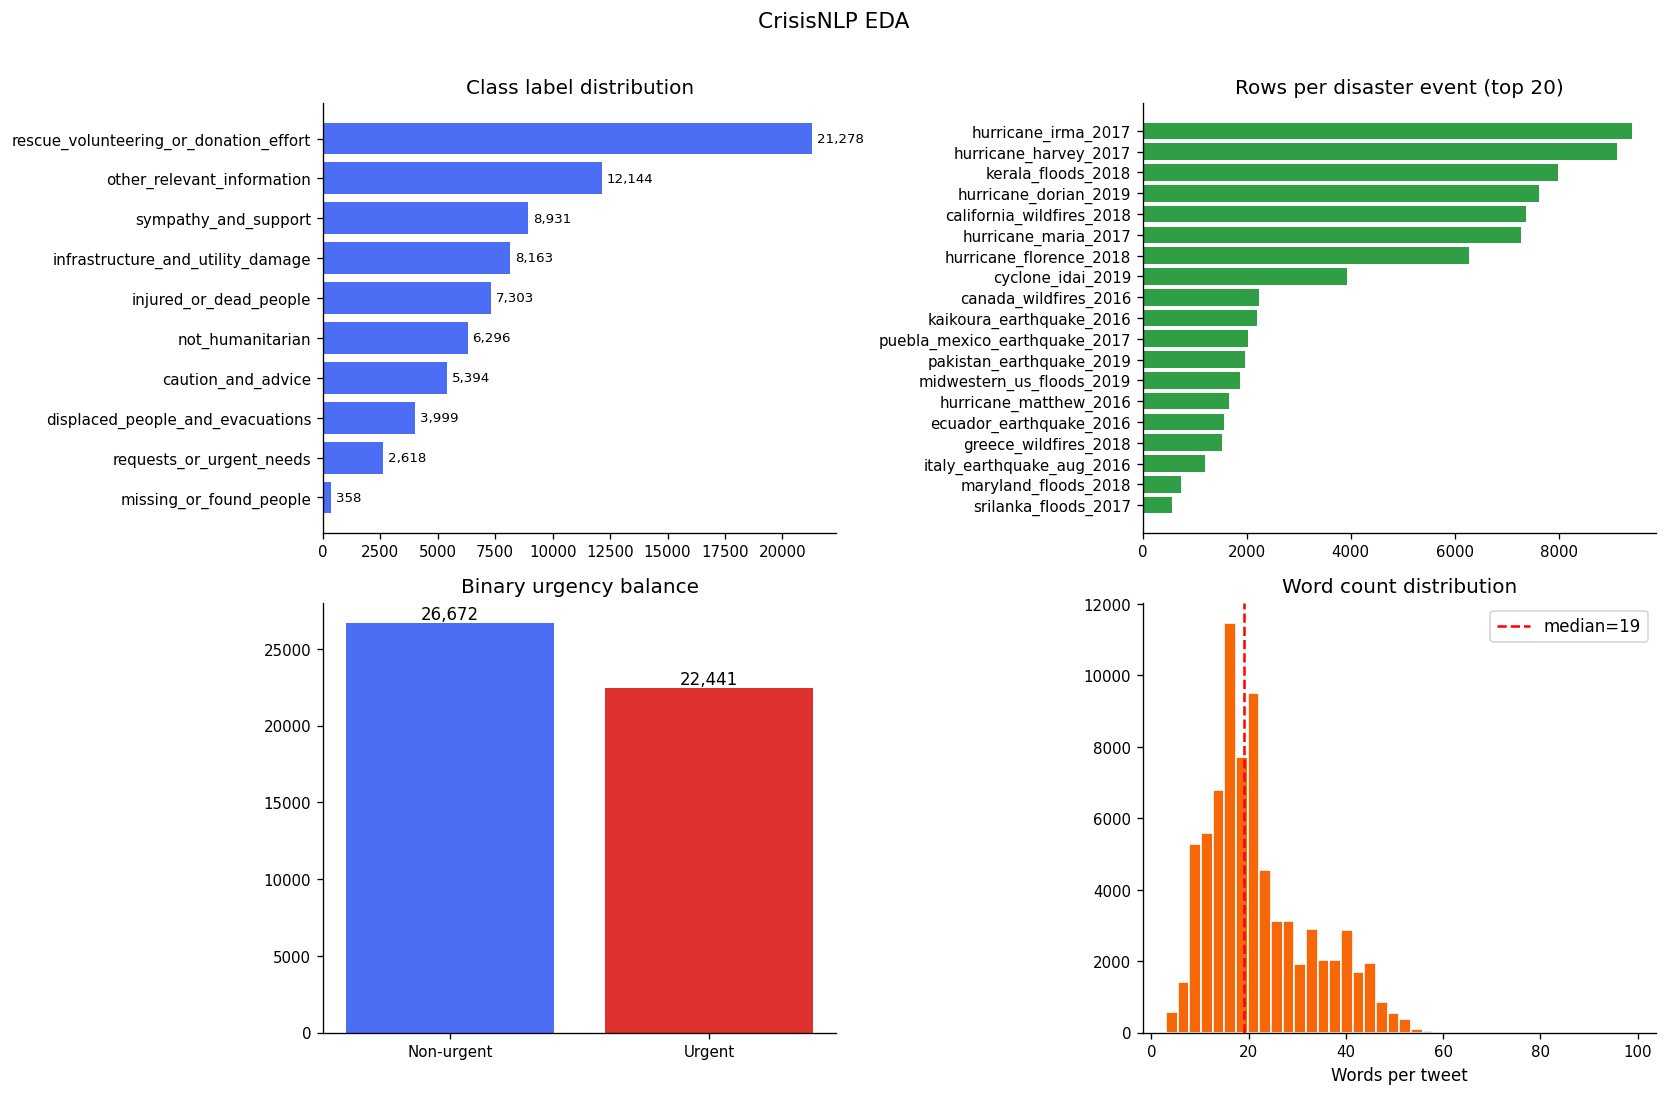

Word count: mean=22.1  median=19  max=99
Est. tokens >128: 0.0%  |  max_length=128 covers 100.0%


In [21]:
section('CrisisNLP — plots')

df_crisis['word_count'] = df_crisis['tweet_text'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Class label distribution
lc = df_crisis['class_label'].value_counts(dropna=False).head(15)
axes[0,0].barh(lc.index.astype(str), lc.values, color=C[0])
axes[0,0].set_title('Class label distribution')
axes[0,0].invert_yaxis()
for i,v in enumerate(lc.values):
    axes[0,0].text(v + lc.max()*0.01, i, f'{v:,}', va='center', fontsize=8)

# 2. Rows per event
ec = df_crisis['event'].value_counts().head(20)
axes[0,1].barh(ec.index, ec.values, color=C[2])
axes[0,1].set_title('Rows per disaster event (top 20)')
axes[0,1].invert_yaxis()

# 3. Urgency balance
urg_c = df_mapped['urgency'].value_counts().sort_index() if len(df_mapped)>0 else pd.Series()
if len(urg_c):
    axes[1,0].bar(['Non-urgent','Urgent'], urg_c.values, color=[C[0],C[3]])
    axes[1,0].set_title('Binary urgency balance')
    for i,v in enumerate(urg_c.values):
        axes[1,0].text(i, v + urg_c.max()*0.01, f'{v:,}', ha='center')

# 4. Word count
axes[1,1].hist(df_crisis['word_count'].dropna(), bins=40, color=C[1], edgecolor='white')
axes[1,1].axvline(df_crisis['word_count'].median(), color='red', linestyle='--',
                  label=f'median={df_crisis["word_count"].median():.0f}')
axes[1,1].set_title('Word count distribution')
axes[1,1].set_xlabel('Words per tweet')
axes[1,1].legend()

plt.suptitle('CrisisNLP EDA', fontsize=13, y=1.01)
plt.tight_layout()
savefig('eda_01_crisisnlp')
plt.show()

wc = df_crisis['word_count']
print(f'Word count: mean={wc.mean():.1f}  median={wc.median():.0f}  max={wc.max()}')
est = wc * 1.3
print(f'Est. tokens >128: {(est>128).mean():.1%}  |  max_length=128 covers {(est<=128).mean():.1%}')


  CrisisNLP — top words & sample rows
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eda_01_crisisnlp_words.png


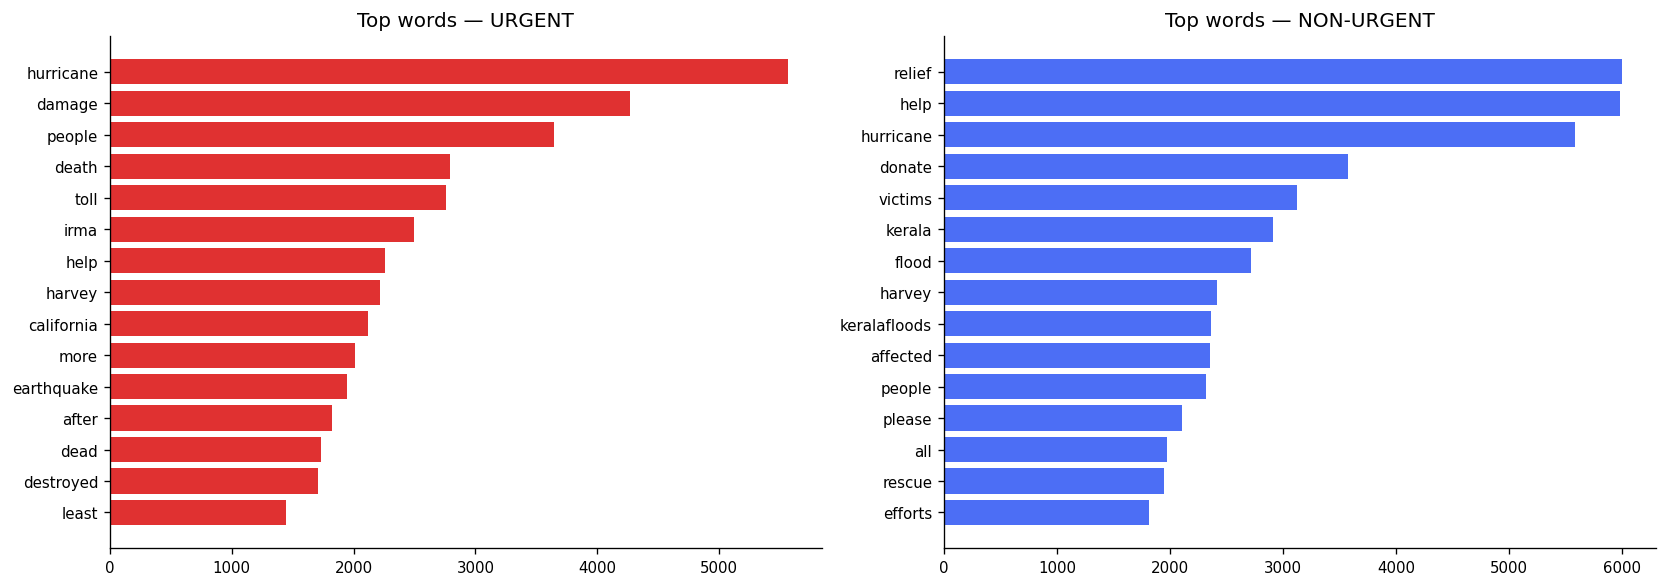


Sample rows:

=== URGENT (3 samples) ===
  [canada_wildfires_2016] [displaced_people_and_evacuations]
  Fort St. John wildfire article updated with #evacuation map  #FortStJohn #wildfires #BC
  [hurricane_irma_2017] [displaced_people_and_evacuations]
  MUST is opening an emergency shelter 4 Irma evacuees Sept. 9. Drop donations @ the Elizabeth Inn @ 55 Elizabeth Church R
  [hurricane_maria_2017] [displaced_people_and_evacuations]
  Puerto Rico is a U.S. Commonwealth. Americans are dying. They cant evacuate, and supplies, medicine are dwindling. Trump

=== NON-URGENT (3 samples) ===
  [hurricane_florence_2018] [caution_and_advice]
  Bracing for Hurricane Florence. In some parts of the country, weather officials predict a level of destruction not seen 
  [hurricane_maria_2017] [rescue_volunteering_or_donation_effort]
  Our useless president isnt doing a damn thing to help our citizens in Puerto Rico. If you have funds you can donate, con
  [hurricane_maria_2017] [rescue_volunteering_or_

In [23]:
section('CrisisNLP — top words & sample rows')

if len(df_mapped) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, urg, title, color in [
        (axes[0], 1, 'URGENT',     C[3]),
        (axes[1], 0, 'NON-URGENT', C[0]),
    ]:
        words = top_words(df_mapped[df_mapped['urgency']==urg]['tweet_text'], 15)
        if not words: continue
        labels, vals = zip(*words)
        ax.barh(range(len(labels)), vals, color=color)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
        ax.invert_yaxis()
        ax.set_title(f'Top words — {title}')
    plt.tight_layout()
    savefig('eda_01_crisisnlp_words')
    plt.show()

print('\nSample rows:')
for urg, label in [(1,'URGENT'),(0,'NON-URGENT')]:
    subset = df_mapped[df_mapped['urgency']==urg]
    print(f'\n=== {label} (3 samples) ===')
    for _, r in subset.sample(min(3,len(subset)), random_state=42).iterrows():
        print(f'  [{r["event"]}] [{r["class_label"]}]')
        print(f'  {r["tweet_text"][:120]}')

---
# 2 — HumAID
`data/raw/humaid/` — HuggingFace Arrow format (train / validation / test)

In [9]:
import pandas as pd
from datasets import load_from_disk
from collections import Counter

def section(t):
    print("\n" + "="*60)
    print(f"  {t}")
    print("="*60)

section('Figure Eight — loading from HF arrow format')

# ── Load from disk ─────────────────────────────────────────────────────────
humaid_path = f'{BASE}/data/raw/humaid'
ds_humaid   = load_from_disk(humaid_path)

print(ds_humaid)
for split in ds_humaid:
    print(f'  {split}: {len(ds_humaid[split]):,} rows')

humaid_frames = []
for split in ds_humaid:
    tmp = ds_humaid[split].to_pandas()
    tmp['source'] = 'figureeight'
    humaid_frames.append(tmp)

df_humaid = pd.concat(humaid_frames, ignore_index=True)
df_humaid.columns = [c.strip().lower() for c in df_humaid.columns]

# Rename text column
if 'message' in df_humaid.columns:
    df_humaid.rename(columns={'message': 'tweet_text'}, inplace=True)
df_humaid['tweet_text'] = df_humaid['tweet_text'].astype(str)

# ── Column definitions (decided in analysis) ───────────────────────────────
URGENCY_COLS = [
    'request', 'medical_help', 'medical_products',
    'search_and_rescue', 'missing_people', 'death',
    'refugees', 'other_aid',
]

SUPPLY_COLS = ['offer', 'aid_centers']

RESOURCE_COLS = {
    'water'           : 'water',
    'food'            : 'food',
    'shelter'         : 'food',
    'medical_help'    : 'medicine',
    'medical_products': 'medicine',
    'hospitals'       : 'medicine',
}

ROUTE_BLOCKER_COLS = [
    'infrastructure_related', 'transport',
    'buildings', 'other_infrastructure',
]

DISASTER_TYPE_COLS = ['floods', 'storm', 'fire', 'earthquake', 'weather_related']

DROP_COLS = [
    'child_alone', 'pii', 'shops', 'tools', 'money',
    'clothing', 'cold', 'security', 'military', 'other_weather',
    'related', 'original', 'genre', 'split', 'source',
]

# ── Drop irrelevant columns ────────────────────────────────────────────────
df_humaid.drop(columns=[c for c in DROP_COLS if c in df_humaid.columns], inplace=True)

# ── Derive urgency, supply, role ───────────────────────────────────────────
df_humaid['urgency']       = df_humaid[[c for c in URGENCY_COLS       if c in df_humaid.columns]].clip(upper=1).max(axis=1).astype(int)
df_humaid['is_supply']     = df_humaid[[c for c in SUPPLY_COLS        if c in df_humaid.columns]].clip(upper=1).max(axis=1).astype(int)
df_humaid['route_blocked'] = df_humaid[[c for c in ROUTE_BLOCKER_COLS if c in df_humaid.columns]].clip(upper=1).max(axis=1).astype(int)
df_humaid['is_reliable']   = df_humaid['direct_report'].clip(upper=1).astype(int) if 'direct_report' in df_humaid.columns else 0

# ── Derive resource_hint list per row ─────────────────────────────────────
def get_resources(row):
    seen = []
    for col, res in RESOURCE_COLS.items():
        if col in row and row[col] == 1 and res not in seen:
            seen.append(res)
    return seen

# ── Derive disaster_type from binary columns ──────────────────────────────
def get_disaster_type(row):
    for col in DISASTER_TYPE_COLS:
        if col in row and row[col] == 1:
            return col
    return 'general'

# ── Derive role: demand / supply / blocker / context ──────────────────────
def get_role(row):
    if row['is_supply']     == 1: return 'supply'
    if row['route_blocked'] == 1: return 'blocker'
    if row['urgency']       == 1: return 'demand'
    return 'context'

df_humaid['resource_hint'] = df_humaid.apply(get_resources, axis=1)
df_humaid['disaster_type'] = df_humaid.apply(get_disaster_type, axis=1)
df_humaid['role']          = df_humaid.apply(get_role, axis=1)
df_humaid['source']        = 'figureeight'

# ── Summary ───────────────────────────────────────────────────────────────
print(f'\nFigure Eight dataset: {len(df_humaid):,} rows  |  {df_humaid.shape[1]} columns')
print(f'\nRole distribution:')
print(df_humaid['role'].value_counts().to_string())
print(f'\nUrgency:')
print(f'  Urgent (1)   : {(df_humaid["urgency"]==1).sum():,}')
print(f'  Non-urgent(0): {(df_humaid["urgency"]==0).sum():,}')
print(f'\nDisaster types:')
print(df_humaid['disaster_type'].value_counts().to_string())
print(f'\nResource hints:')
all_res = [r for sub in df_humaid['resource_hint'] for r in sub]
print(Counter(all_res))
print(f'\nReliable (eyewitness) tweets: {df_humaid["is_reliable"].sum():,}')
print(f'\nFinal columns: {list(df_humaid.columns)}')

# ── Save to Drive ─────────────────────────────────────────────────────────
out_path = f'{config.DATA_PROC}/figureeight_mapped.csv'
df_humaid.to_csv(out_path, index=False)
print(f'\n✓ Saved -> {out_path}')


  Figure Eight — loading from HF arrow format
DatasetDict({
    train: Dataset({
        features: ['split', 'message', 'original', 'genre', 'related', 'PII', 'request', 'offer', 'aid_related', 'medical_help', 'medical_products', 'search_and_rescue', 'security', 'military', 'child_alone', 'water', 'food', 'shelter', 'clothing', 'money', 'missing_people', 'refugees', 'death', 'other_aid', 'infrastructure_related', 'transport', 'buildings', 'electricity', 'tools', 'hospitals', 'shops', 'aid_centers', 'other_infrastructure', 'weather_related', 'floods', 'storm', 'fire', 'earthquake', 'cold', 'other_weather', 'direct_report'],
        num_rows: 21046
    })
    test: Dataset({
        features: ['split', 'message', 'original', 'genre', 'related', 'PII', 'request', 'offer', 'aid_related', 'medical_help', 'medical_products', 'search_and_rescue', 'security', 'military', 'child_alone', 'water', 'food', 'shelter', 'clothing', 'money', 'missing_people', 'refugees', 'death', 'other_aid', 'infras


  Figure Eight — Exploratory Data Analysis
Shape      : (26248, 35)
Rows       : 26,248
Columns    : 35
Nulls      : 0 null texts
Duplicates : 72 duplicate tweets

Tweet length (chars):
count    26248.000000
mean       144.751981
std        207.171514
min          0.000000
25%         75.000000
50%        124.000000
75%        179.000000
max      10818.000000

Word count:
count    26248.000000
mean        23.855379
std         32.169406
min          0.000000
25%         13.000000
50%         21.000000
75%         29.000000
max       1686.000000


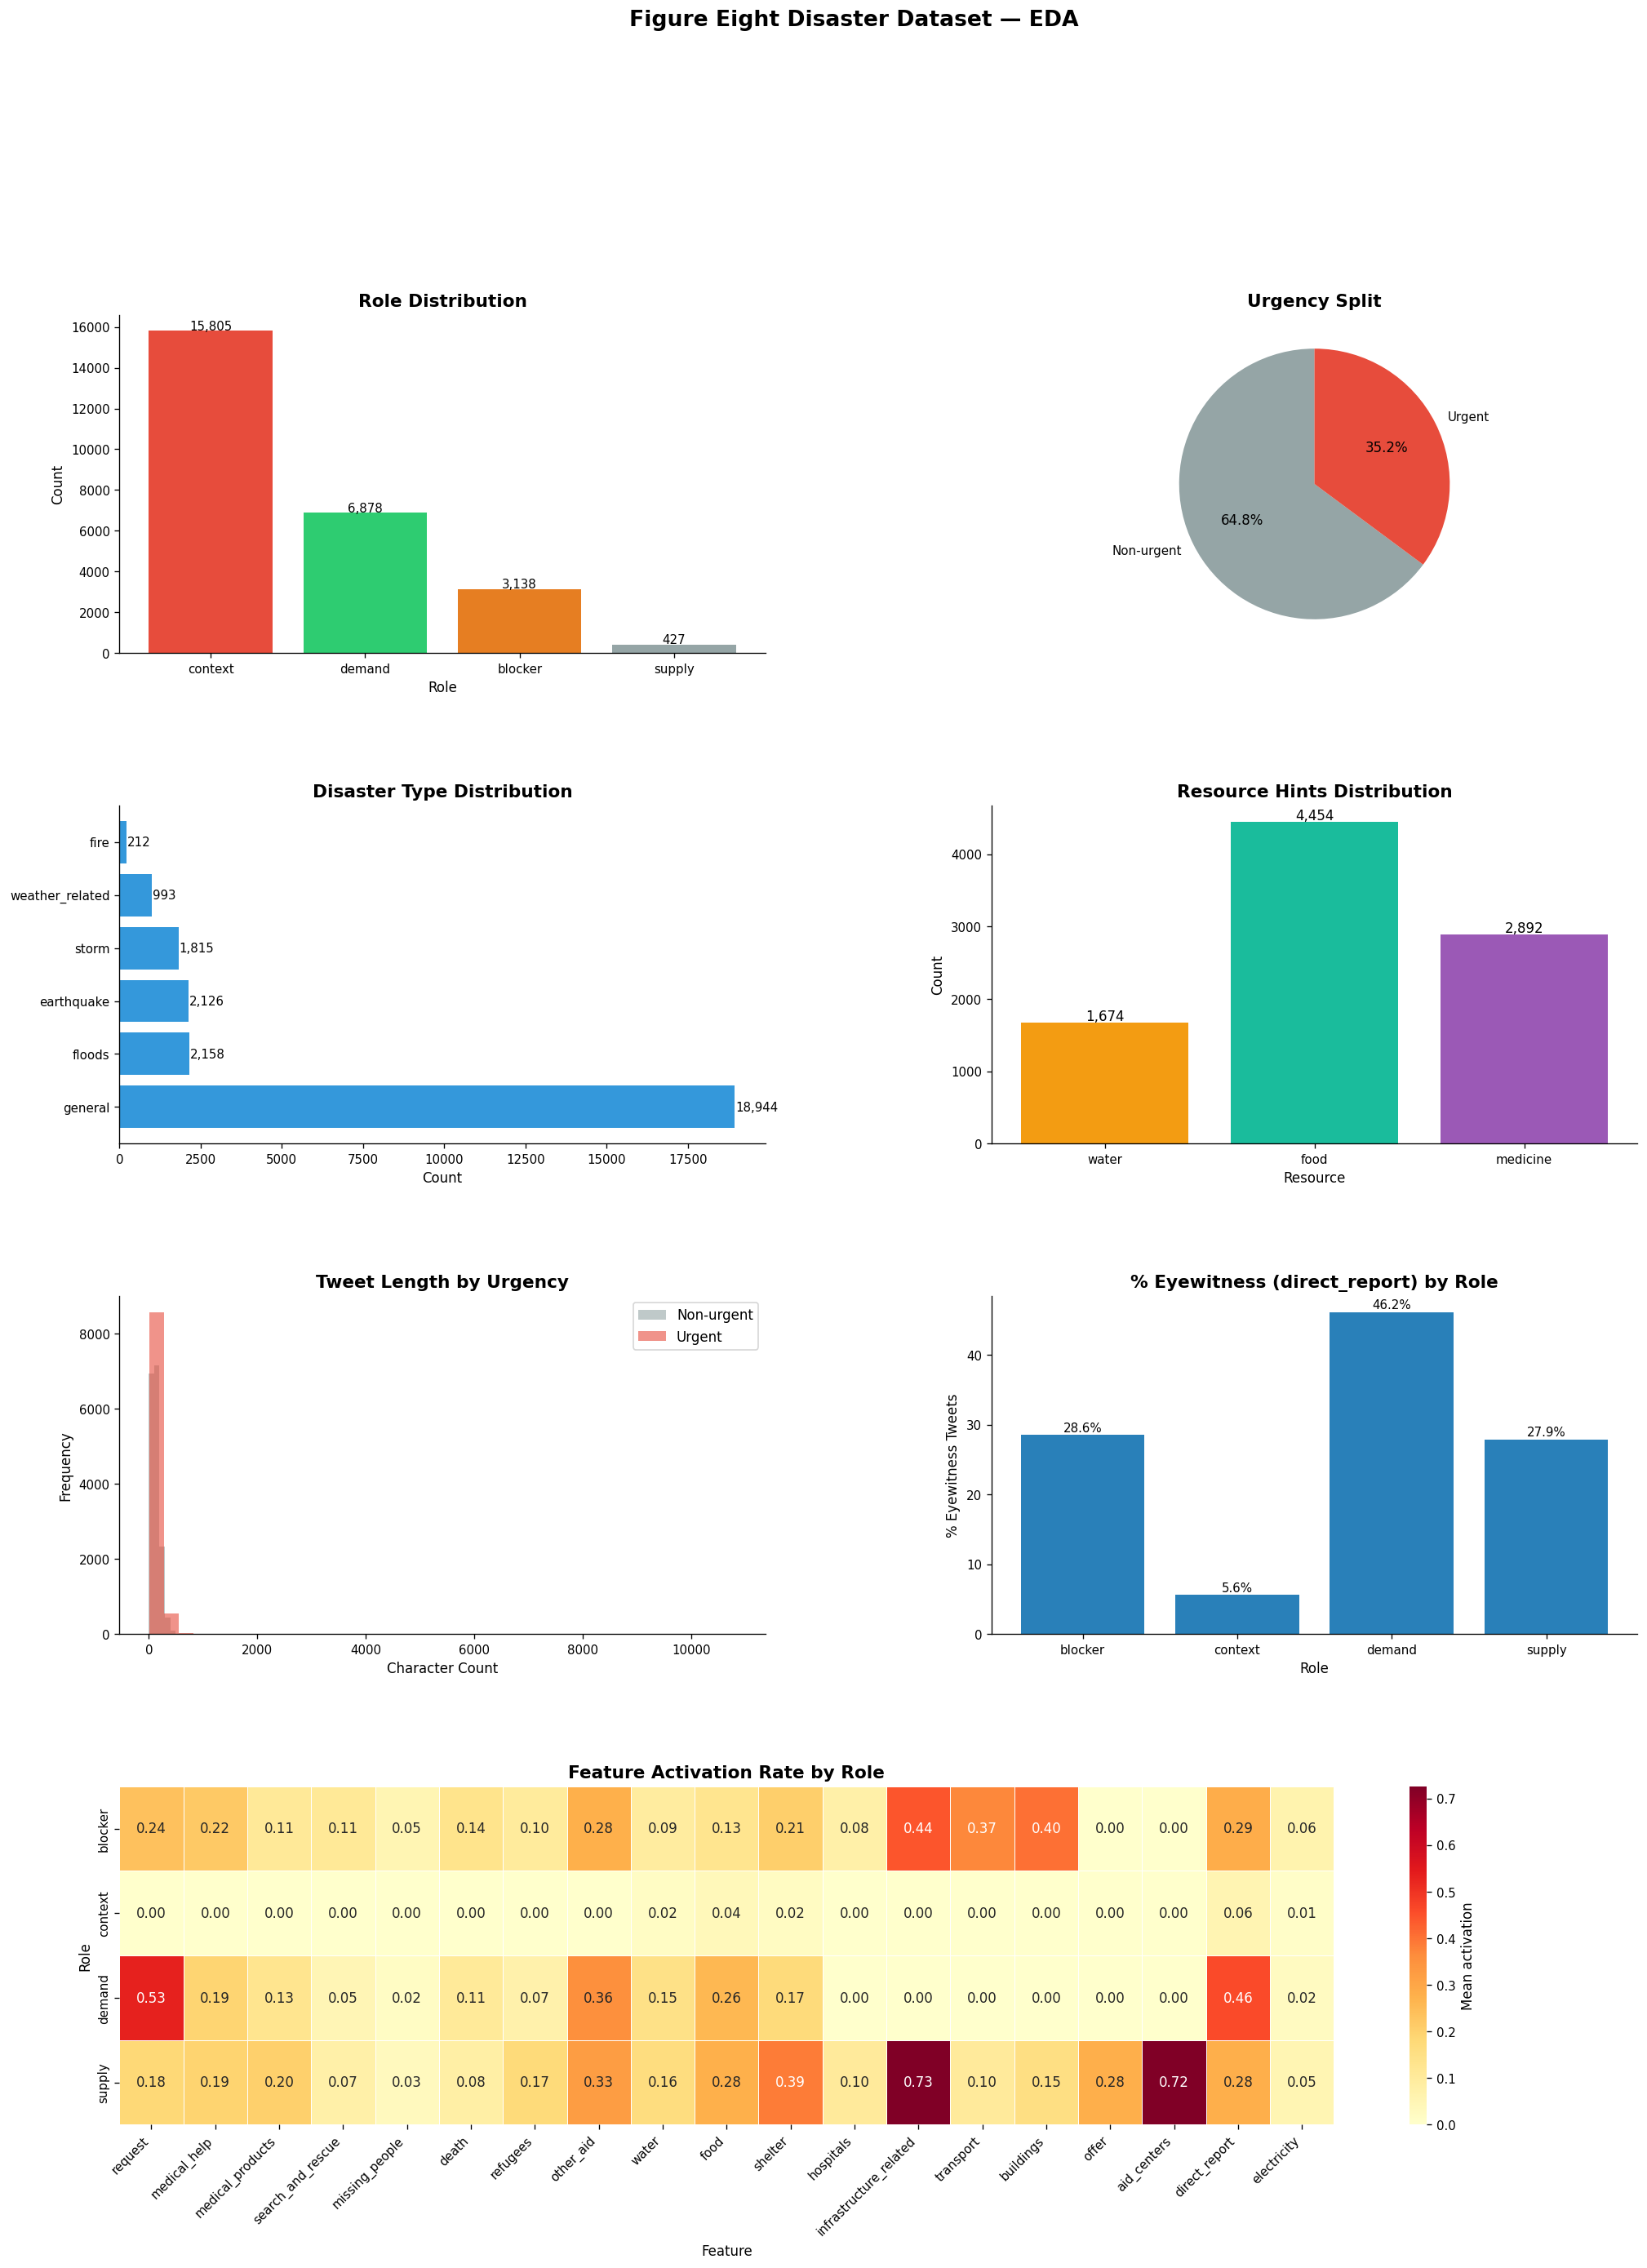

✓ Saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/figureeight_eda.png

--- Key Insights ---
1. Class imbalance  : 35.2% urgent vs 64.8% non-urgent
   → Will need class weighting or oversampling in Week 3 training
2. Dominant role    : context (15,805 rows = 60.2%)
   → Most tweets are observational, not actionable
3. Top resource     : food (4,454 mentions)
4. Eyewitness tweets: 5,081 (19.4%)
   → Upweight these in demand vector construction (Week 3)
5. Dominant disaster: general (18,944 = 72.2% labelled general)
   → Disaster type tagging is sparse; NER will need to fill this gap (Week 2)


In [30]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from collections import Counter

section('Figure Eight — Exploratory Data Analysis')

# ── 1. Basic shape ─────────────────────────────────────────────────────────
print(f'Shape      : {df_humaid.shape}')
print(f'Rows       : {len(df_humaid):,}')
print(f'Columns    : {df_humaid.shape[1]}')
print(f'Nulls      : {df_humaid["tweet_text"].isna().sum()} null texts')
print(f'Duplicates : {df_humaid["tweet_text"].duplicated().sum()} duplicate tweets')

# ── 2. Tweet length stats ──────────────────────────────────────────────────
df_humaid['text_len']  = df_humaid['tweet_text'].str.len()
df_humaid['word_count']= df_humaid['tweet_text'].str.split().str.len()

print(f'\nTweet length (chars):')
print(df_humaid['text_len'].describe().to_string())
print(f'\nWord count:')
print(df_humaid['word_count'].describe().to_string())

# ── 3. Plots ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1 — Role distribution
ax1 = fig.add_subplot(gs[0, 0])
role_counts = df_humaid['role'].value_counts()
bars = ax1.bar(role_counts.index, role_counts.values,
               color=['#e74c3c','#2ecc71','#e67e22','#95a5a6'])
ax1.set_title('Role Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Role')
ax1.set_ylabel('Count')
for bar, val in zip(bars, role_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', fontsize=9)

# Plot 2 — Urgency split
ax2 = fig.add_subplot(gs[0, 1])
urg_counts = df_humaid['urgency'].value_counts().sort_index()
ax2.pie(urg_counts.values,
        labels=['Non-urgent', 'Urgent'],
        autopct='%1.1f%%',
        colors=['#95a5a6', '#e74c3c'],
        startangle=90)
ax2.set_title('Urgency Split', fontsize=13, fontweight='bold')

# Plot 3 — Disaster type distribution
ax3 = fig.add_subplot(gs[1, 0])
dtype_counts = df_humaid['disaster_type'].value_counts()
ax3.barh(dtype_counts.index, dtype_counts.values, color='#3498db')
ax3.set_title('Disaster Type Distribution', fontsize=13, fontweight='bold')
ax3.set_xlabel('Count')
for i, val in enumerate(dtype_counts.values):
    ax3.text(val + 30, i, f'{val:,}', va='center', fontsize=9)

# Plot 4 — Resource hints
ax4 = fig.add_subplot(gs[1, 1])
all_res = [r for sub in df_humaid['resource_hint'] for r in sub]
res_counts = Counter(all_res)
ax4.bar(res_counts.keys(), res_counts.values(),
        color=['#f39c12', '#1abc9c', '#9b59b6'])
ax4.set_title('Resource Hints Distribution', fontsize=13, fontweight='bold')
ax4.set_xlabel('Resource')
ax4.set_ylabel('Count')
for i, (k, v) in enumerate(res_counts.items()):
    ax4.text(i, v + 30, f'{v:,}', ha='center', fontsize=10)

# Plot 5 — Tweet length distribution by urgency
ax5 = fig.add_subplot(gs[2, 0])
for urgency, color, label in [(0, '#95a5a6', 'Non-urgent'), (1, '#e74c3c', 'Urgent')]:
    subset = df_humaid[df_humaid['urgency'] == urgency]['text_len']
    ax5.hist(subset, bins=40, alpha=0.6, color=color, label=label)
ax5.set_title('Tweet Length by Urgency', fontsize=13, fontweight='bold')
ax5.set_xlabel('Character Count')
ax5.set_ylabel('Frequency')
ax5.legend()

# Plot 6 — Reliable vs non-reliable by role
ax6 = fig.add_subplot(gs[2, 1])
reliable_by_role = df_humaid.groupby('role')['is_reliable'].mean() * 100
ax6.bar(reliable_by_role.index, reliable_by_role.values, color='#2980b9')
ax6.set_title('% Eyewitness (direct_report) by Role', fontsize=13, fontweight='bold')
ax6.set_xlabel('Role')
ax6.set_ylabel('% Eyewitness Tweets')
for i, val in enumerate(reliable_by_role.values):
    ax6.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

# Plot 7 — Binary feature heatmap (mean value per role)
ax7 = fig.add_subplot(gs[3, :])
binary_cols = ['request', 'medical_help', 'medical_products', 'search_and_rescue',
               'missing_people', 'death', 'refugees', 'other_aid',
               'water', 'food', 'shelter', 'hospitals',
               'infrastructure_related', 'transport', 'buildings',
               'offer', 'aid_centers', 'direct_report', 'electricity']
binary_cols = [c for c in binary_cols if c in df_humaid.columns]

heatmap_data = df_humaid.groupby('role')[binary_cols].mean()
sns.heatmap(heatmap_data, ax=ax7, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'Mean activation'})
ax7.set_title('Feature Activation Rate by Role', fontsize=13, fontweight='bold')
ax7.set_xlabel('Feature')
ax7.set_ylabel('Role')
plt.setp(ax7.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Figure Eight Disaster Dataset — EDA', fontsize=16, fontweight='bold', y=1.01)
plt.savefig(f'{config.OUT_PLOTS}/figureeight_eda.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Saved -> {config.OUT_PLOTS}/figureeight_eda.png')

# ── 4. Key insights summary ────────────────────────────────────────────────
print('\n--- Key Insights ---')
print(f'1. Class imbalance  : {(df_humaid["urgency"]==1).mean()*100:.1f}% urgent vs {(df_humaid["urgency"]==0).mean()*100:.1f}% non-urgent')
print(f'   → Will need class weighting or oversampling in Week 3 training')
print(f'2. Dominant role    : {role_counts.index[0]} ({role_counts.values[0]:,} rows = {role_counts.values[0]/len(df_humaid)*100:.1f}%)')
print(f'   → Most tweets are observational, not actionable')
print(f'3. Top resource     : {max(res_counts, key=res_counts.get)} ({max(res_counts.values()):,} mentions)')
print(f'4. Eyewitness tweets: {df_humaid["is_reliable"].sum():,} ({df_humaid["is_reliable"].mean()*100:.1f}%)')
print(f'   → Upweight these in demand vector construction (Week 3)')
print(f'5. Dominant disaster: {dtype_counts.index[0]} ({dtype_counts.values[0]:,} = {dtype_counts.values[0]/len(df_humaid)*100:.1f}% labelled general)')
print(f'   → Disaster type tagging is sparse; NER will need to fill this gap (Week 2)')

---
# 3 — WikiANN NER
`data/raw/wikiannn/en/`, `hi/`, `ta/` — HF arrow format

In [31]:
section('WikiANN — loading')

TAG_NAMES = {0:'O',1:'B-PER',2:'I-PER',3:'B-ORG',4:'I-ORG',5:'B-LOC',6:'I-LOC'}
wikiann = {}

for lang in ['en','hi','ta']:
    path = f'{BASE}/data/raw/wikiannn/{lang}'
    if os.path.exists(path):
        ds = load_from_disk(path)
        wikiann[lang] = ds
        splits = {s: len(ds[s]) for s in ds}
        print(f'[{lang}]  splits={splits}  features={list(ds["train"].features.keys())}')
        row = ds['train'][0]
        print(f'  tokens : {row["tokens"][:10]}')
        print(f'  tags   : {[TAG_NAMES.get(t,"?") for t in row["ner_tags"][:10]]}')
    else:
        print(f'[{lang}] NOT FOUND at {path}')


  WikiANN — loading
[en]  splits={'validation': 10000, 'test': 10000, 'train': 20000}  features=['tokens', 'ner_tags', 'langs', 'spans']
  tokens : ['R.H.', 'Saunders', '(', 'St.', 'Lawrence', 'River', ')', '(', '968', 'MW']
  tags   : ['B-ORG', 'I-ORG', 'O', 'B-ORG', 'I-ORG', 'I-ORG', 'O', 'O', 'O', 'O']
[hi]  splits={'validation': 1000, 'test': 1000, 'train': 5000}  features=['tokens', 'ner_tags', 'langs', 'spans']
  tokens : ['टैपी', 'ने', 'अपने', 'उत्पादों', 'को', 'एशिया', 'के', 'अपतटीय', 'भागों', 'में']
  tags   : ['O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O']
[ta]  splits={'validation': 1000, 'test': 1000, 'train': 15000}  features=['tokens', 'ner_tags', 'langs', 'spans']
  tokens : ['இங்கிருக்கும்', 'அரச', 'மரம்', 'தேவனம்பியதீச', 'மன்னன்', 'காலத்திலேயே', 'அனுராதபுரத்திலிருக்கும்', 'சிறீ', 'மகாபோதியிலிருந்து', 'முதலாவதாகப்']
  tags   : ['O', 'B-LOC', 'I-LOC', 'B-PER', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'O']



  WikiANN — tag distribution & sequence length
[en] total tokens=160,394  entity%=49.3%
  B-LOC: 9,345 (5.83%)
  B-ORG: 9,422 (5.87%)
  B-PER: 9,164 (5.71%)
  I-LOC: 13,177 (8.22%)
  I-ORG: 23,226 (14.48%)
  I-PER: 14,698 (9.16%)
[hi] total tokens=29,443  entity%=56.1%
  B-LOC: 2,040 (6.93%)
  B-ORG: 1,823 (6.19%)
  B-PER: 2,261 (7.68%)
  I-LOC: 1,901 (6.46%)
  I-ORG: 5,252 (17.84%)
  I-PER: 3,248 (11.03%)
[ta] total tokens=108,174  entity%=39.1%
  B-LOC: 6,791 (6.28%)
  B-ORG: 5,497 (5.08%)
  B-PER: 6,206 (5.74%)
  I-LOC: 3,693 (3.41%)
  I-ORG: 11,591 (10.72%)
  I-PER: 8,482 (7.84%)
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eda_03_wikiann.png


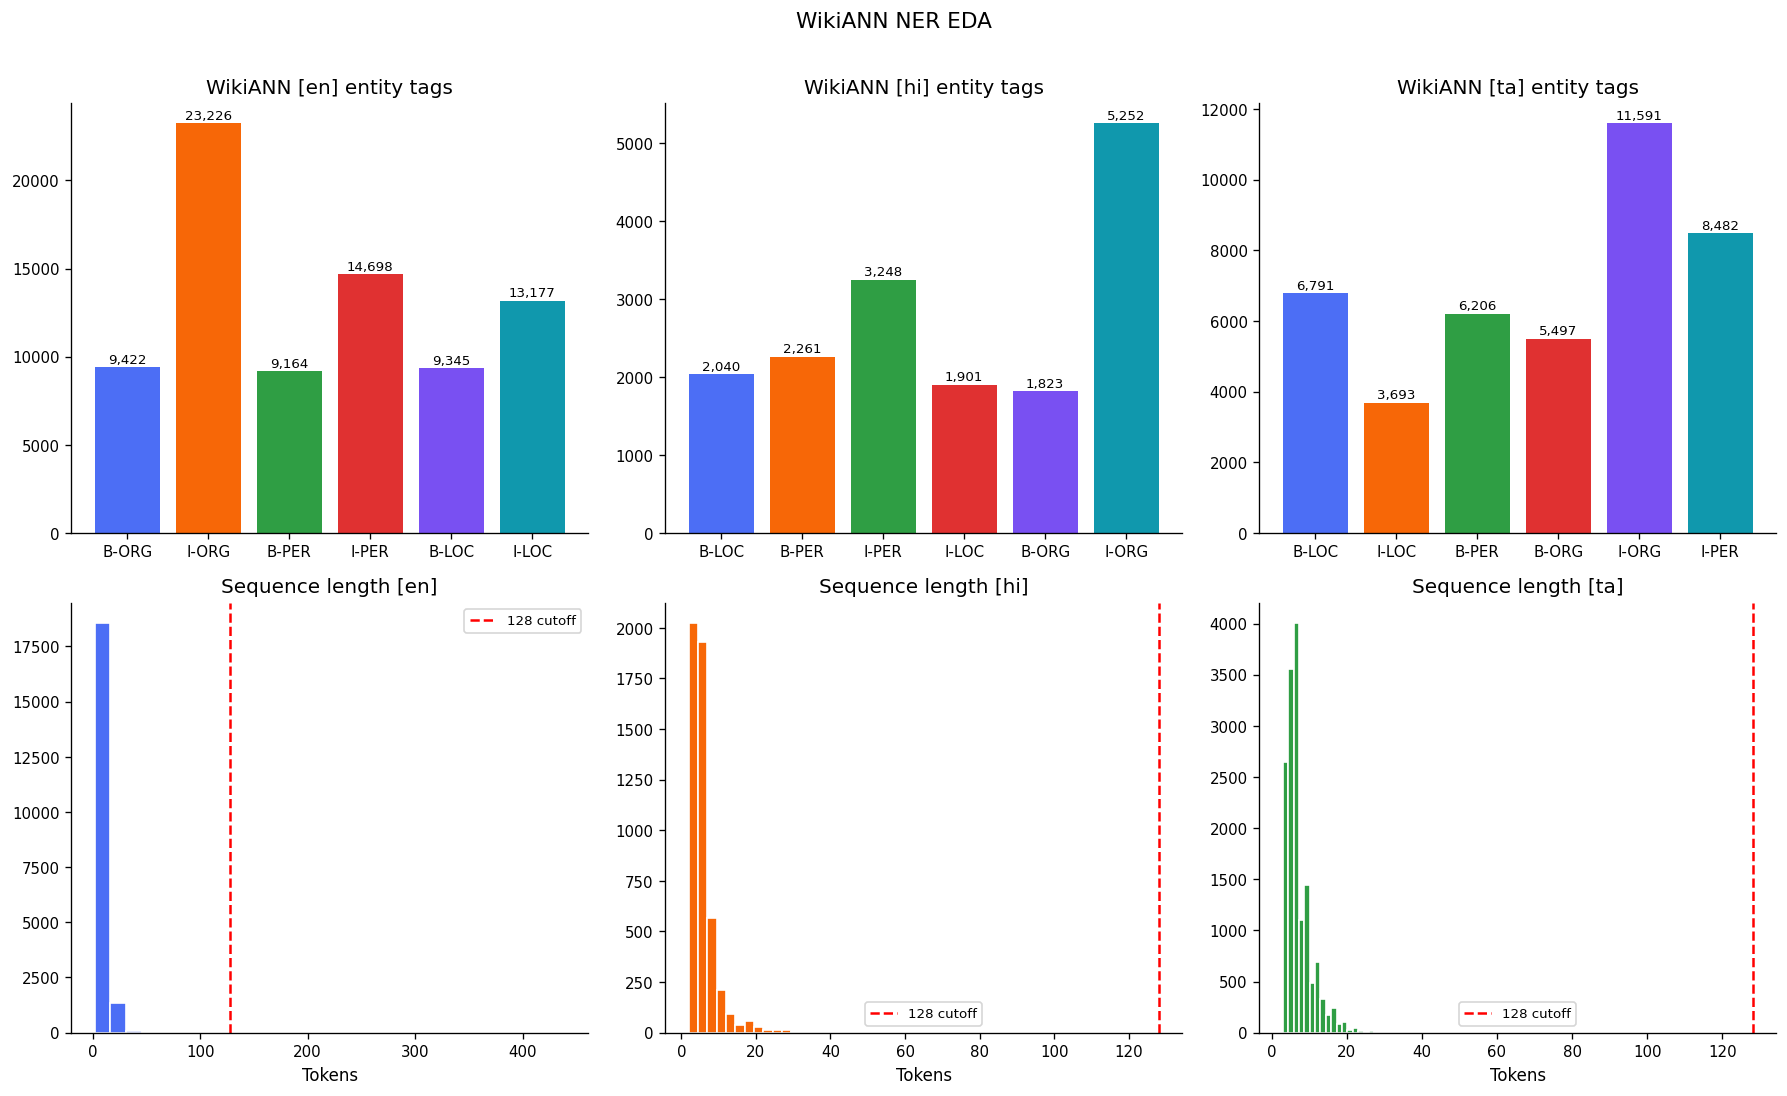


Lang      Tokens   Entity%   SeqMean   SeqMax  Over128    B-LOC
--------------------------------------------------------------
en       160,394     49.3%       8.0      439     0.0%    9,345
hi        29,443     56.1%       5.9       77     0.0%    2,040
ta       108,174     39.1%       7.2       46     0.0%    6,791


In [32]:
section('WikiANN — tag distribution & sequence length')

ncols = max(len(wikiann), 1)
fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 9))
if ncols == 1:
    axes = axes.reshape(2, 1)

wiki_stats = {}
for col, (lang, ds) in enumerate(wikiann.items()):
    df_w = ds['train'].to_pandas()
    seq_lens = df_w['tokens'].apply(len)
    all_tags = [TAG_NAMES.get(t,'?') for tags in df_w['ner_tags'] for t in tags]
    tag_cnt  = Counter(all_tags)
    ent_cnt  = {k:v for k,v in tag_cnt.items() if k != 'O'}
    o_count  = tag_cnt.get('O', 0)
    total    = sum(tag_cnt.values())

    wiki_stats[lang] = {
        'total':total, 'entity_rate':(total-o_count)/total,
        'seq_mean':seq_lens.mean(), 'seq_max':seq_lens.max(),
        'over_128':(seq_lens>128).mean(), 'B-LOC':ent_cnt.get('B-LOC',0)
    }

    print(f'[{lang}] total tokens={total:,}  entity%={(total-o_count)/total:.1%}')
    for tag, cnt in sorted(ent_cnt.items()):
        print(f'  {tag}: {cnt:,} ({cnt/total:.2%})')

    labels_e = list(ent_cnt.keys())
    vals_e   = [ent_cnt[k] for k in labels_e]
    axes[0][col].bar(labels_e, vals_e, color=C[:len(labels_e)])
    axes[0][col].set_title(f'WikiANN [{lang}] entity tags')
    for i,v in enumerate(vals_e):
        axes[0][col].text(i, v + max(vals_e)*0.01, f'{v:,}', ha='center', fontsize=8)

    axes[1][col].hist(seq_lens, bins=30, color=C[col%len(C)], edgecolor='white')
    axes[1][col].axvline(128, color='red', linestyle='--', label='128 cutoff')
    axes[1][col].set_title(f'Sequence length [{lang}]')
    axes[1][col].set_xlabel('Tokens')
    axes[1][col].legend(fontsize=8)

plt.suptitle('WikiANN NER EDA', fontsize=13, y=1.01)
plt.tight_layout()
savefig('eda_03_wikiann')
plt.show()

print(f'\n{"Lang":<5} {"Tokens":>10} {"Entity%":>9} {"SeqMean":>9} {"SeqMax":>8} {"Over128":>8} {"B-LOC":>8}')
print('-'*62)
for lang, s in wiki_stats.items():
    print(f'{lang:<5} {s["total"]:>10,} {s["entity_rate"]:>9.1%} {s["seq_mean"]:>9.1f} {s["seq_max"]:>8} {s["over_128"]:>8.1%} {s["B-LOC"]:>8,}')

In [33]:
section('WikiANN — annotated sample sentences')

for lang, ds in wikiann.items():
    df_w = ds['train'].to_pandas()
    has_ent = df_w['ner_tags'].apply(lambda t: any(x>0 for x in t))
    samples = df_w[has_ent].sample(min(3, has_ent.sum()), random_state=42)
    print(f'\n[{lang}] 3 samples with entities:')
    for _, row in samples.iterrows():
        annotated = [f'{tok}[{TAG_NAMES.get(t,"?")}]' if t>0 else tok
                     for tok, t in zip(row['tokens'], row['ner_tags'])]
        print(f'  {" ".join(annotated[:25])}')

print('\nIMPORTANT: WikiANN LOC = country/city names (Wikipedia).')
print('Disaster locations (camps, shelters) are NOT well represented.')
print('-> Keyword fallback in Stage 7 is essential.')


  WikiANN — annotated sample sentences

[en] 3 samples with entities:
  Stratford[B-LOC] ,[I-LOC] Oklahoma[I-LOC]
  Anders[B-PER] Behring[I-PER] Breivik[I-PER]
  '' The[B-ORG] World[I-ORG] as[I-ORG] Best[I-ORG] as[I-ORG] I[I-ORG] Remember[I-ORG] It[I-ORG] ,[I-ORG] Volume[I-ORG] Two[I-ORG] '' ( 1992 )

[hi] 3 samples with entities:
  '' झारखण्ड[B-LOC] '' '
  जगदलपुर[B-LOC] से 39 किमी .
  मजापहित[B-ORG] साम्राज्य[I-ORG] , इंडोनेशिया[B-LOC] का सम्राट।

[ta] 3 samples with entities:
  இதில் பவன்[B-PER] கல்யாண்[I-PER] , அமீஷா[B-PER] பட்டேல்[I-PER] ஆகியோர் நடித்திருந்தனர் .
  கே.[B-PER] ஆர்.[I-PER] விஜயா[I-PER] -தெய்வானையாக
  இவற்றுள் பெரியது சிவனுக்கு[B-ORG] உரிய கோயிலாகும் .

IMPORTANT: WikiANN LOC = country/city names (Wikipedia).
Disaster locations (camps, shelters) are NOT well represented.
-> Keyword fallback in Stage 7 is essential.


---
# 5 — FIRE 2021
`data/raw/fire2021/` — Dravidian code-mix (Tamil+English / Malayalam+English)

In [35]:
section('FIRE 2021 — discovering files')

fire_path  = f'{BASE}/data/raw/fire2021'
fire_files = sorted(Path(fire_path).rglob('*'))
df_fire    = None

if fire_files:
    for f in fire_files:
        if f.is_file():
            print(f'  {f.relative_to(fire_path)}  ({f.stat().st_size:,} bytes)')
else:
    print(f'  Empty at {fire_path}.')
    print('  Sources:')
    print('    https://github.com/kmi-linguistics/Dravidian-CodeMix-SentimentAnalysis')
    print('    https://dravidian-codemix.github.io/2021/')


  FIRE 2021 — discovering files
  Empty at /content/drive/MyDrive/Equi-Relief/data/raw/fire2021.
  Sources:
    https://github.com/kmi-linguistics/Dravidian-CodeMix-SentimentAnalysis
    https://dravidian-codemix.github.io/2021/


In [36]:
section('FIRE 2021 — loading & EDA')

frames_fire = []
for f in fire_files:
    f = str(f)
    if not os.path.isfile(f): continue
    try:
        if f.endswith('.csv'):  tmp = pd.read_csv(f)
        elif f.endswith('.tsv'): tmp = pd.read_csv(f, sep='\t')
        elif f.endswith('.xlsx'): tmp = pd.read_excel(f)
        else: continue
        tmp.columns = [c.strip().lower() for c in tmp.columns]
        tmp['source_file'] = os.path.basename(f)
        frames_fire.append(tmp)
        print(f'  {os.path.basename(f)}  {tmp.shape}  cols={list(tmp.columns)}')
    except Exception as e:
        print(f'  ERROR {f}: {e}')

if frames_fire:
    df_fire = pd.concat(frames_fire, ignore_index=True)
    text_col  = next((c for c in df_fire.columns if c in ('text','sentence','comment')), df_fire.columns[0])
    label_col = next((c for c in df_fire.columns if c in ('label','category','sentiment')), df_fire.columns[-1])
    print(f'\nRows: {len(df_fire):,}  |  text={text_col}  label={label_col}')
    print('\nLabel distribution:')
    print(df_fire[label_col].value_counts().to_string())

    def tamil_ratio(text):
        t = str(text)
        return sum(1 for c in t if 0x0B80 <= ord(c) <= 0x0BFF) / max(len(t), 1)

    df_fire['tamil_ratio'] = df_fire[text_col].apply(tamil_ratio)
    df_fire['script_type'] = df_fire['tamil_ratio'].apply(
        lambda r: 'Pure Tamil' if r>=0.8 else ('Tanglish' if r>0 else 'Roman only')
    )
    df_fire['word_count']  = df_fire[text_col].astype(str).str.split().str.len()

    disaster_kws = ['flood','earthquake','cyclone','relief','rescue','sos','emergency']
    df_fire['has_disaster'] = df_fire[text_col].astype(str).str.lower().apply(
        lambda t: any(kw in t for kw in disaster_kws)
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    lc = df_fire[label_col].value_counts()
    axes[0].barh(lc.index.astype(str), lc.values, color=C[4])
    axes[0].invert_yaxis()
    axes[0].set_title('Label distribution')

    sc = df_fire['script_type'].value_counts()
    axes[1].bar(sc.index, sc.values, color=[C[0],C[1],C[2]][:len(sc)])
    axes[1].set_title('Script type breakdown')
    for i,v in enumerate(sc.values): axes[1].text(i, v+sc.max()*0.01, f'{v:,}', ha='center', fontsize=9)

    axes[2].hist(df_fire['word_count'], bins=30, color=C[5], edgecolor='white')
    axes[2].set_title(f'Word count  |  disaster kw: {df_fire["has_disaster"].mean():.1%}')
    axes[2].set_xlabel('Words')

    plt.suptitle('FIRE 2021 EDA', fontsize=13, y=1.01)
    plt.tight_layout()
    savefig('eda_05_fire2021')
    plt.show()

    print('\nSample Tanglish rows:')
    tang = df_fire[df_fire['script_type']=='Tanglish']
    for _, r in tang.sample(min(4,len(tang)), random_state=42).iterrows():
        print(f'  [{r[label_col]}]  {str(r[text_col])[:100]}')

    print(f'\nConclusion: FIRE 2021 is sentiment data, {df_fire["has_disaster"].mean():.0%} disaster overlap.')
    print('USE: Stage 2 Tanglish language detection only.')
else:
    print('FIRE 2021 empty. EDA skipped. Your 60 Tanglish test samples are the primary reference.')


  FIRE 2021 — loading & EDA
FIRE 2021 empty. EDA skipped. Your 60 Tanglish test samples are the primary reference.


---
# 6 — Kerala & Chennai Floods (synthetic JSON)

In [13]:
section('Floods — loading synthetic JSONs')

flood_paths = {
    'Kerala 2018' : f'{BASE}/data/raw/kerala_floods/synthetic_sample.json',
    'Chennai 2015': f'{BASE}/data/raw/chennai_floods/synthetic_sample.json',
}

flood_frames = {}
for name, path in flood_paths.items():
    if os.path.exists(path):
        data = utils.load_json(path)
        df_f = pd.DataFrame(data)
        flood_frames[name] = df_f
        print(f'{name}: {len(df_f)} rows')
        print(f'  Columns  : {list(df_f.columns)}')
        print(f'  Languages: {df_f["lang"].value_counts().to_dict()}')
        print(f'  Districts: {df_f["district"].unique().tolist()}')
        print()
        print(df_f[['id','lang','district','text']].to_string(index=False))
        print()
    else:
        print(f'{name}: NOT FOUND at {path}')

df_floods = None
if flood_frames:
    df_floods = pd.concat(flood_frames.values(), ignore_index=True)


  Floods — loading synthetic JSONs
Kerala 2018: 6 rows
  Columns  : ['id', 'text', 'lang', 'district']
  Languages: {'en': 3, 'hinglish': 2, 'ml': 1}
  Districts: ['Ernakulam', 'Thrissur', 'Alappuzha', 'Pathanamthitta', 'Wayanad']

   id     lang       district                                                             text
kl001       en      Ernakulam              Water level rising in Aluva, need boats immediately
kl002       ml      Ernakulam                      ആലുവയിൽ വെള്ളം കയറി, ഉടൻ ഭക്ഷണം ആവശ്യമുണ്ട്
kl003 hinglish       Thrissur             Chalakudy me paani bahut zyada hai, please help karo
kl004       en      Alappuzha                        Medicine needed at Chengannur relief camp
kl005 hinglish Pathanamthitta Pathanamthitta district mein log phanse hue hain, rescue chahiye
kl006       en        Wayanad             Wayanad hospitals overcrowded, need medical supplies

Chennai 2015: 6 rows
  Columns  : ['id', 'text', 'lang', 'district']
  Languages: {'en': 3, 'tanglish


  Floods — language & district plots
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eda_06_floods.png


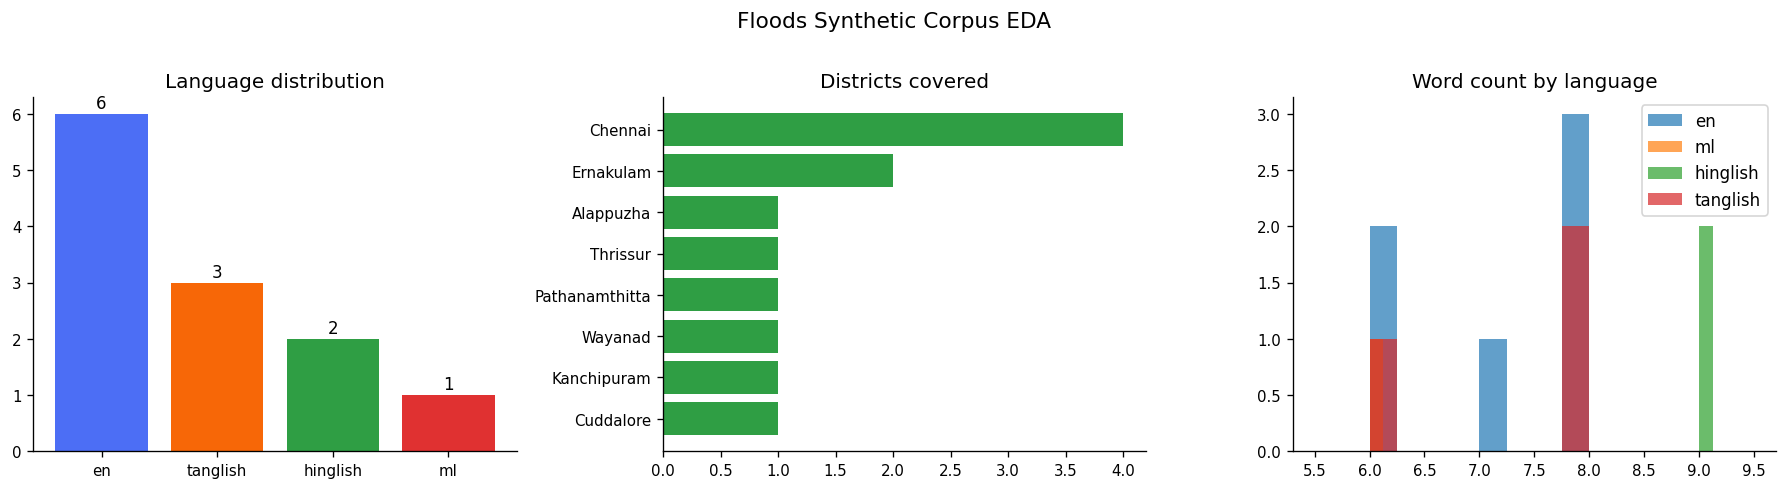

District x language cross-tab:
lang            en  hinglish  ml  tanglish
district                                  
Alappuzha        1         0   0         0
Chennai          3         0   0         1
Cuddalore        0         0   0         1
Ernakulam        1         0   1         0
Kanchipuram      0         0   0         1
Pathanamthitta   0         1   0         0
Thrissur         0         1   0         0
Wayanad          1         0   0         0

-> Real disaster domain + multilingual. Used for end-to-end pipeline testing.


In [38]:
section('Floods — language & district plots')

if df_floods is not None:
    df_floods['word_count'] = df_floods['text'].str.split().str.len()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    lc = df_floods['lang'].value_counts()
    axes[0].bar(lc.index, lc.values, color=C[:len(lc)])
    axes[0].set_title('Language distribution')
    for i,v in enumerate(lc.values): axes[0].text(i, v+0.1, str(v), ha='center')

    dc = df_floods['district'].value_counts()
    axes[1].barh(dc.index, dc.values, color=C[2])
    axes[1].set_title('Districts covered')
    axes[1].invert_yaxis()

    for lang in df_floods['lang'].unique():
        s = df_floods[df_floods['lang']==lang]['word_count']
        axes[2].hist(s, bins=8, alpha=0.7, label=lang)
    axes[2].set_title('Word count by language')
    axes[2].legend()

    plt.suptitle('Floods Synthetic Corpus EDA', fontsize=13, y=1.01)
    plt.tight_layout()
    savefig('eda_06_floods')
    plt.show()

    print('District x language cross-tab:')
    print(pd.crosstab(df_floods['district'], df_floods['lang']).to_string())
    print('\n-> Real disaster domain + multilingual. Used for end-to-end pipeline testing.')

---
# 7 — Manual Test Set (180 samples)

In [11]:
section('Manual test set — loading all files')

test_files = {
    'hinglish': f'{BASE}/data/test_set/hinglish_test.json',
    'tanglish': f'{BASE}/data/test_set/tanglish_test.json',
    'mixed'   : f'{BASE}/data/test_set/mixed_test.json',
    'combined': f'{BASE}/data/test_set/combined_180.json',
}

for name, path in test_files.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path) if exists else 0
    count  = len(utils.load_json(path)) if exists else 0
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status}] {name:<10} {count:>4} samples  {size:>8,} bytes  {path}')

df_test = pd.DataFrame(utils.load_json(test_files['combined']))
df_test['word_count'] = df_test['text'].str.split().str.len()
print(f'\nShape: {df_test.shape}  |  Columns: {list(df_test.columns)}')
df_test.head(3)


  Manual test set — loading all files
  [OK] hinglish     60 samples    15,791 bytes  /content/drive/MyDrive/Equi-Relief/data/test_set/hinglish_test.json
  [OK] tanglish     60 samples    15,291 bytes  /content/drive/MyDrive/Equi-Relief/data/test_set/tanglish_test.json
  [OK] mixed        60 samples    17,337 bytes  /content/drive/MyDrive/Equi-Relief/data/test_set/mixed_test.json
  [OK] combined    180 samples    48,415 bytes  /content/drive/MyDrive/Equi-Relief/data/test_set/combined_180.json

Shape: (180, 9)  |  Columns: ['id', 'text', 'lang', 'urgency', 'resources', 'location', 'disaster_type', 'region', 'word_count']


,id,text,lang,urgency,resources,location,disaster_type,region,word_count
0,hi001,"Yaar flood aa gaya, khaana chahiye urgently north sector mein",hinglish,1,[food],north sector,flood,north,10
1,hi002,"Bhaiya please khana bhejo, 2 din se kuch nahi mila east camp",hinglish,1,[food],east camp,flood,east,12
2,hi003,"Relief camp mein khana khatam ho gaya, immediately send karo",hinglish,1,[food],relief camp,general,central,10



  Manual test set — distributions
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eda_07_testset.png


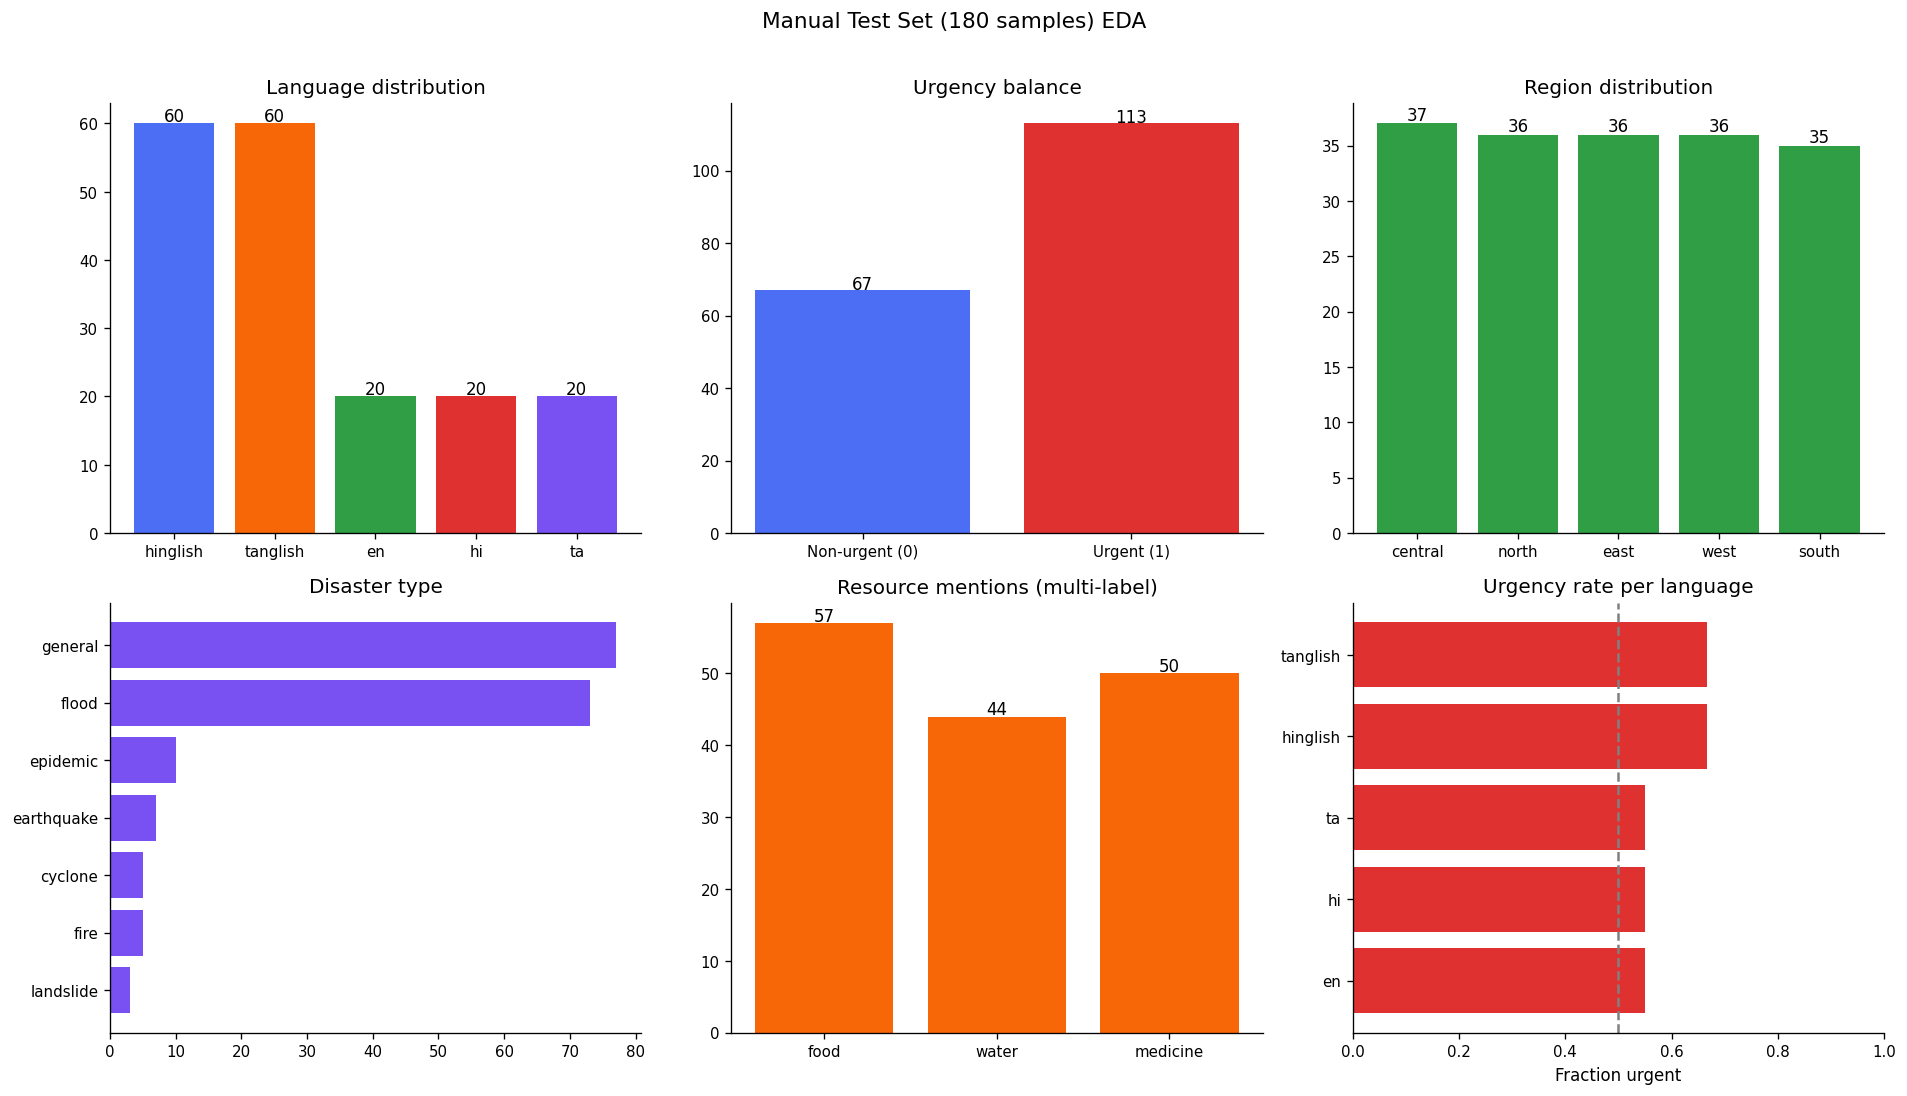

In [40]:
section('Manual test set — distributions')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

lc = df_test['lang'].value_counts()
axes[0,0].bar(lc.index, lc.values, color=C[:len(lc)])
axes[0,0].set_title('Language distribution')
for i,v in enumerate(lc.values): axes[0,0].text(i, v+0.3, str(v), ha='center')

uc = df_test['urgency'].value_counts().sort_index()
axes[0,1].bar(['Non-urgent (0)','Urgent (1)'], uc.values, color=[C[0],C[3]])
axes[0,1].set_title('Urgency balance')
for i,v in enumerate(uc.values): axes[0,1].text(i, v+0.3, str(v), ha='center')

rc = df_test['region'].value_counts()
axes[0,2].bar(rc.index, rc.values, color=C[2])
axes[0,2].set_title('Region distribution')
for i,v in enumerate(rc.values): axes[0,2].text(i, v+0.3, str(v), ha='center')

dc = df_test['disaster_type'].value_counts()
axes[1,0].barh(dc.index, dc.values, color=C[4])
axes[1,0].set_title('Disaster type')
axes[1,0].invert_yaxis()

all_res = [r for lst in df_test['resources'] for r in lst]
res_cnt = Counter(all_res)
axes[1,1].bar(res_cnt.keys(), res_cnt.values(), color=C[1])
axes[1,1].set_title('Resource mentions (multi-label)')
for i,v in enumerate(res_cnt.values()): axes[1,1].text(i, v+0.3, str(v), ha='center')

ul = df_test.groupby('lang')['urgency'].mean().sort_values()
axes[1,2].barh(ul.index, ul.values,
               color=[C[3] if v>0.5 else C[0] for v in ul.values])
axes[1,2].axvline(0.5, linestyle='--', color='gray')
axes[1,2].set_title('Urgency rate per language')
axes[1,2].set_xlabel('Fraction urgent')
axes[1,2].set_xlim(0, 1)

plt.suptitle('Manual Test Set (180 samples) EDA', fontsize=13, y=1.01)
plt.tight_layout()
savefig('eda_07_testset')
plt.show()


  Manual test set — coverage heatmaps
Urgency x Language:
urgency    0    1  Total
lang                    
en         9   11     20
hi         9   11     20
hinglish  20   40     60
ta         9   11     20
tanglish  20   40     60
Total     67  113    180

Urgency x Region:
urgency   0    1  Total
region                 
central  12   25     37
east     15   21     36
north    11   25     36
south    10   25     35
west     19   17     36
Total    67  113    180
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eda_07_testset_coverage.png


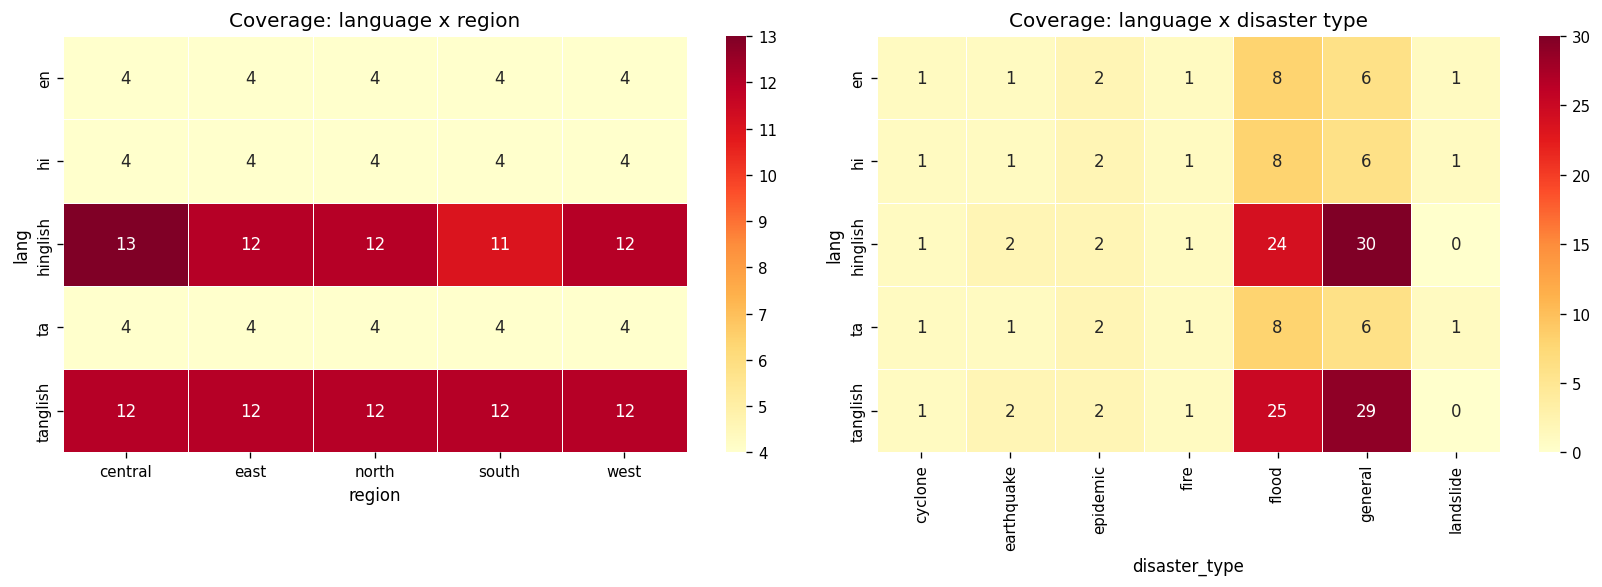


All (lang x region) pairs covered.

Word count by language:
          count  mean  std  min  25%   50%   75%   max
lang                                                  
en         20.0   8.3  1.5  7.0  7.0   8.0   9.0  13.0
hi         20.0   8.6  1.5  7.0  7.0   8.0   9.0  12.0
hinglish   60.0   9.9  1.3  7.0  9.0  10.0  11.0  12.0
ta         20.0   5.2  1.0  3.0  4.8   5.0   6.0   7.0
tanglish   60.0   7.5  1.2  5.0  7.0   7.0   8.0  10.0


In [41]:
section('Manual test set — coverage heatmaps')

print('Urgency x Language:')
print(pd.crosstab(df_test['lang'], df_test['urgency'],
                  margins=True, margins_name='Total').to_string())

print('\nUrgency x Region:')
print(pd.crosstab(df_test['region'], df_test['urgency'],
                  margins=True, margins_name='Total').to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cov_lr = pd.crosstab(df_test['lang'], df_test['region'])
sns.heatmap(cov_lr, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0], linewidths=0.5)
axes[0].set_title('Coverage: language x region')

cov_ld = pd.crosstab(df_test['lang'], df_test['disaster_type'])
sns.heatmap(cov_ld, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('Coverage: language x disaster type')

plt.tight_layout()
savefig('eda_07_testset_coverage')
plt.show()

zeros = [(l,r) for l in cov_lr.index for r in cov_lr.columns if cov_lr.loc[l,r]==0]
if zeros:
    print(f'\nMissing (lang, region) pairs:')
    for p in zeros: print(f'  {p}')
else:
    print('\nAll (lang x region) pairs covered.')

print('\nWord count by language:')
print(df_test.groupby('lang')['word_count'].describe().round(1).to_string())

---
# 8 — Combined Master + Gap Analysis

In [17]:
from collections import Counter

# ── Map CrisisNLP labels → urgency/role/resource ──────────────────────────
URGENCY_LABELS = {
    'requests_or_urgent_needs'              : 1,
    'injured_or_dead_people'                : 1,
    'infrastructure_and_utility_damage'     : 1,
    'displaced_people_and_evacuations'      : 1,
    'missing_or_found_people'               : 1,
    'caution_and_advice'                    : 0,
    'rescue_volunteering_or_donation_effort': 0,
}
ROLE_MAP = {
    'requests_or_urgent_needs'              : 'demand',
    'injured_or_dead_people'                : 'demand',
    'infrastructure_and_utility_damage'     : 'blocker',
    'displaced_people_and_evacuations'      : 'demand',
    'missing_or_found_people'               : 'demand',
    'caution_and_advice'                    : 'context',
    'rescue_volunteering_or_donation_effort': 'supply',
}
RESOURCE_MAP = {
    'requests_or_urgent_needs'              : ['food', 'water', 'medicine'],
    'injured_or_dead_people'                : ['medicine'],
    'infrastructure_and_utility_damage'     : [],
    'displaced_people_and_evacuations'      : ['food', 'water'],
    'missing_or_found_people'               : [],
    'caution_and_advice'                    : [],
    'rescue_volunteering_or_donation_effort': ['food', 'water', 'medicine'],
}

df_crisis_clean = df_crisis[
    df_crisis['class_label'].isin(URGENCY_LABELS)
].copy()

df_crisis_clean['urgency']       = df_crisis_clean['class_label'].map(URGENCY_LABELS)
df_crisis_clean['role']          = df_crisis_clean['class_label'].map(ROLE_MAP)
df_crisis_clean['resource_hint'] = df_crisis_clean['class_label'].map(RESOURCE_MAP)
df_crisis_clean['is_reliable']   = 0
df_crisis_clean['is_supply']     = (df_crisis_clean['role'] == 'supply').astype(int)
df_crisis_clean['route_blocked'] = (df_crisis_clean['role'] == 'blocker').astype(int)
df_crisis_clean['disaster_type'] = 'general'
df_crisis_clean['source']        = 'humaid_tsv'

print(f'✓ CrisisNLP mapped: {len(df_crisis_clean):,} rows')

# ── Align Figure Eight columns to match CrisisNLP ─────────────────────────
MASTER_COLS = [
    'tweet_text', 'urgency', 'role', 'resource_hint',
    'is_reliable', 'is_supply', 'route_blocked',
    'disaster_type', 'source'
]

df_crisis_master   = df_crisis_clean[MASTER_COLS].copy()
df_humaid_master   = df_humaid[MASTER_COLS].copy()

# ── Merge into master ─────────────────────────────────────────────────────
df_master = pd.concat([df_crisis_master, df_humaid_master], ignore_index=True)

# Clean up
df_master['tweet_text']    = df_master['tweet_text'].astype(str).str.strip()
df_master['resource_hint'] = df_master['resource_hint'].apply(
    lambda x: x if isinstance(x, list) else eval(x) if isinstance(x, str) else []
)
df_master.drop_duplicates(subset='tweet_text', inplace=True)
df_master.reset_index(drop=True, inplace=True)

# ── Save ──────────────────────────────────────────────────────────────────
master_path = f'{BASE}/data/processed/master_clean.csv'
df_master.to_csv(master_path, index=False)

# ── Summary ───────────────────────────────────────────────────────────────
print(f'\n{"="*50}')
print(f'MASTER DATASET SUMMARY')
print(f'{"="*50}')
print(f'Total rows       : {len(df_master):,}')
print(f'Unique tweets    : {df_master["tweet_text"].nunique():,}')
print(f'\nBy source:')
print(df_master['source'].value_counts().to_string())
print(f'\nRole distribution:')
print(df_master['role'].value_counts().to_string())
print(f'\nUrgency:')
print(f'  Urgent (1)   : {(df_master["urgency"]==1).sum():,}')
print(f'  Non-urgent(0): {(df_master["urgency"]==0).sum():,}')
print(f'\nDisaster types:')
print(df_master['disaster_type'].value_counts().to_string())
print(f'\nResource hints:')
all_res = [r for sub in df_master['resource_hint'] for r in sub]
print(Counter(all_res))
print(f'\n✓ Saved -> {master_path}')


✓ CrisisNLP mapped: 49,113 rows

MASTER DATASET SUMMARY
Total rows       : 75,280
Unique tweets    : 75,280

By source:
source
humaid_tsv     49110
figureeight    26170

Role distribution:
role
supply     21700
context    21157
demand     21133
blocker    11290

Urgency:
  Urgent (1)   : 31,638
  Non-urgent(0): 43,642

Disaster types:
disaster_type
general            67996
floods              2149
earthquake          2123
storm               1809
weather_related      991
fire                 212

Resource hints:
Counter({'medicine': 34081, 'food': 32325, 'water': 29562})

✓ Saved -> /content/drive/MyDrive/Equi-Relief/data/processed/master_clean.csv


In [18]:
section('Building combined master DataFrame')

master_frames = []

# ── 1. CrisisNLP (76k rows) ───────────────────────────────────────────────
try:
    _ = df_crisis_clean.head(1)
    fc = df_crisis_clean[[
        'tweet_text', 'class_label', 'urgency', 'role',
        'resource_hint', 'is_reliable', 'is_supply',
        'route_blocked', 'disaster_type', 'event', 'split', 'source'
    ]].copy()
    fc.rename(columns={'tweet_text': 'text'}, inplace=True)
    fc['lang']   = 'en'
    fc['region'] = 'unknown'
    fc['set']    = 'crisisnlp'
    master_frames.append(fc)
    print(f'CrisisNLP        : {len(fc):,} rows')
except NameError:
    print('✗ df_crisis_clean not in scope — run Cell B first')

# ── 2. Figure Eight / HumAID (26k rows) ───────────────────────────────────
try:
    _ = df_humaid.head(1)
    fh = df_humaid[[
        'tweet_text', 'urgency', 'role',
        'resource_hint', 'is_reliable', 'is_supply',
        'route_blocked', 'disaster_type', 'source'
    ]].copy()
    fh.rename(columns={'tweet_text': 'text'}, inplace=True)
    fh['lang']        = 'en'
    fh['region']      = 'unknown'
    fh['event']       = 'figureeight'
    fh['split']       = 'train'
    fh['set']         = 'figureeight'
    fh['class_label'] = fh['urgency'].map({
        1: 'requests_or_urgent_needs',
        0: 'other_relevant_information'
    })
    master_frames.append(fh)
    print(f'Figure Eight     : {len(fh):,} rows')
except NameError:
    print('✗ df_humaid not in scope — run Cell B first')

# ── 3. Manual test set (180 rows) ─────────────────────────────────────────
try:
    _ = df_test.head(1)
    ft = df_test[[
        'id', 'text', 'lang', 'urgency',
        'region', 'resources', 'disaster_type'
    ]].copy()
    ft.rename(columns={
        'id'           : 'tweet_id',
        'disaster_type': 'event',
        'resources'    : 'resource_hint'
    }, inplace=True)
    ft['class_label']  = ft['urgency'].map({
        1: 'requests_or_urgent_needs',
        0: 'other_relevant_information'
    })
    ft['split']        = 'test'
    ft['set']          = 'manual'
    ft['source']       = 'manual_test_set'
    ft['is_reliable']  = 0
    ft['is_supply']    = 0
    ft['route_blocked']= 0
    ft['role']         = ft['urgency'].map({1: 'demand', 0: 'context'})
    master_frames.append(ft)
    print(f'Manual test set  : {len(ft):,} rows')
except NameError:
    print('✗ df_test not in scope — skipping')

# ── 4. Floods synthetic (Kerala + Chennai) ────────────────────────────────
try:
    if df_floods is not None:
        ff = df_floods[['id', 'text', 'lang']].copy()
        ff.rename(columns={'id': 'tweet_id'}, inplace=True)
        ff['urgency']      = 1
        ff['class_label']  = 'requests_or_urgent_needs'
        ff['role']         = 'demand'
        ff['resource_hint']= [['food', 'water']] * len(ff)
        ff['event']        = 'flood'
        ff['split']        = 'test'
        ff['set']          = 'floods'
        ff['source']       = 'floods_synthetic'
        ff['region']       = 'unknown'
        ff['is_reliable']  = 0
        ff['is_supply']    = 0
        ff['route_blocked']= 0
        ff['disaster_type']= 'floods'
        master_frames.append(ff)
        print(f'Floods synthetic : {len(ff):,} rows')
    else:
        print('⚠ df_floods is None — skipping')
except NameError:
    print('✗ df_floods not in scope — skipping')

# ── 5. Concatenate all ────────────────────────────────────────────────────
if not master_frames:
    print('ERROR: No dataframes loaded — check cells above')
else:
    # Align columns — fill missing with None
    ALL_COLS = [
        'text', 'lang', 'urgency', 'class_label', 'role',
        'resource_hint', 'is_reliable', 'is_supply', 'route_blocked',
        'disaster_type', 'event', 'split', 'set', 'source', 'region'
    ]
    aligned = []
    for frame in master_frames:
        for col in ALL_COLS:
            if col not in frame.columns:
                frame[col] = None
        aligned.append(frame[ALL_COLS])

    df_master = pd.concat(aligned, ignore_index=True)

    # Clean text
    df_master['text'] = df_master['text'].astype(str).str.strip()

    # Fix resource_hint — ensure every row is a list
    def fix_resource(x):
        if isinstance(x, list):  return x
        if isinstance(x, str) and x.startswith('['): return eval(x)
        if pd.isna(x):           return []
        return []
    df_master['resource_hint'] = df_master['resource_hint'].apply(fix_resource)

    # Remove exact duplicate texts (keep first)
    before = len(df_master)
    df_master.drop_duplicates(subset='text', inplace=True)
    df_master.reset_index(drop=True, inplace=True)
    after = len(df_master)

    # ── Save ──────────────────────────────────────────────────────────────
    master_path = f'{BASE}/data/processed/master_clean.csv'
    df_master.to_csv(master_path, index=False)

    # ── Summary ───────────────────────────────────────────────────────────
    print(f'\n{"="*55}')
    print(f'  MASTER DATASET SUMMARY')
    print(f'{"="*55}')
    print(f'Total rows       : {len(df_master):,}  (removed {before-after:,} duplicates)')
    print(f'\nBy source:')
    print(df_master['source'].value_counts().to_string())
    print(f'\nBy language:')
    print(df_master['lang'].value_counts().to_string())
    print(f'\nBy split:')
    print(df_master['split'].value_counts().to_string())
    print(f'\nRole distribution:')
    print(df_master['role'].value_counts().to_string())
    print(f'\nUrgency:')
    print(f'  Urgent (1)   : {(df_master["urgency"]==1).sum():,}')
    print(f'  Non-urgent(0): {(df_master["urgency"]==0).sum():,}')
    print(f'\nResource hints (top resources):')
    from collections import Counter
    all_res = [r for sub in df_master['resource_hint'] for r in sub]
    print(Counter(all_res))
    print(f'\n✓ Saved -> {master_path}')


  Building combined master DataFrame
CrisisNLP        : 49,113 rows
Figure Eight     : 26,248 rows
Manual test set  : 180 rows
Floods synthetic : 12 rows

  MASTER DATASET SUMMARY
Total rows       : 75,472  (removed 81 duplicates)

By source:
source
humaid_tsv          49110
figureeight         26170
manual_test_set       180
floods_synthetic       12

By language:
lang
en          75306
tanglish       63
hinglish       62
hi             20
ta             20
ml              1

By split:
split
train    60542
test      9927
dev       5003

Role distribution:
role
supply     21700
demand     21258
context    21224
blocker    11290

Urgency:
  Urgent (1)   : 31,763
  Non-urgent(0): 43,709

Resource hints (top resources):
Counter({'medicine': 34131, 'food': 32394, 'water': 29618})

✓ Saved -> /content/drive/MyDrive/Equi-Relief/data/processed/master_clean.csv


In [19]:
section('Cleaning master DataFrame')

before = len(df_master)
df_master = df_master[df_master['text'].notna()]
df_master = df_master[df_master['text'].str.strip().str.len() > 0]
df_master = df_master[~df_master['text'].str.match(r'^https?://\S+$', na=False)]
df_master = (
    df_master
    .sort_values('urgency', ascending=False)
    .drop_duplicates(subset='text', keep='first')
    .reset_index(drop=True)
)
after = len(df_master)

print(f'Before: {before:,}  ->  After: {after:,}  (dropped {before-after:,} = {(before-after)/before:.1%})')
print(f'\nFinal:')
print(f'  Sources   : {df_master["source"].value_counts().to_dict()}')
print(f'  Languages : {df_master["lang"].value_counts().to_dict()}')
print(f'  Urgency   : urgent={df_master["urgency"].sum():,}  non-urgent={(df_master["urgency"]==0).sum():,}')
print(f'  Balance   : {df_master["urgency"].mean():.1%} urgent')


  Cleaning master DataFrame
Before: 75,472  ->  After: 75,470  (dropped 2 = 0.0%)

Final:
  Sources   : {'humaid_tsv': 49110, 'figureeight': 26168, 'manual_test_set': 180, 'floods_synthetic': 12}
  Languages : {'en': 75304, 'tanglish': 63, 'hinglish': 62, 'ta': 20, 'hi': 20, 'ml': 1}
  Urgency   : urgent=31,763  non-urgent=43,707
  Balance   : 42.1% urgent



  Master — overview plots
  saved -> /content/drive/MyDrive/Equi-Relief/outputs/plots/eda_08_master.png


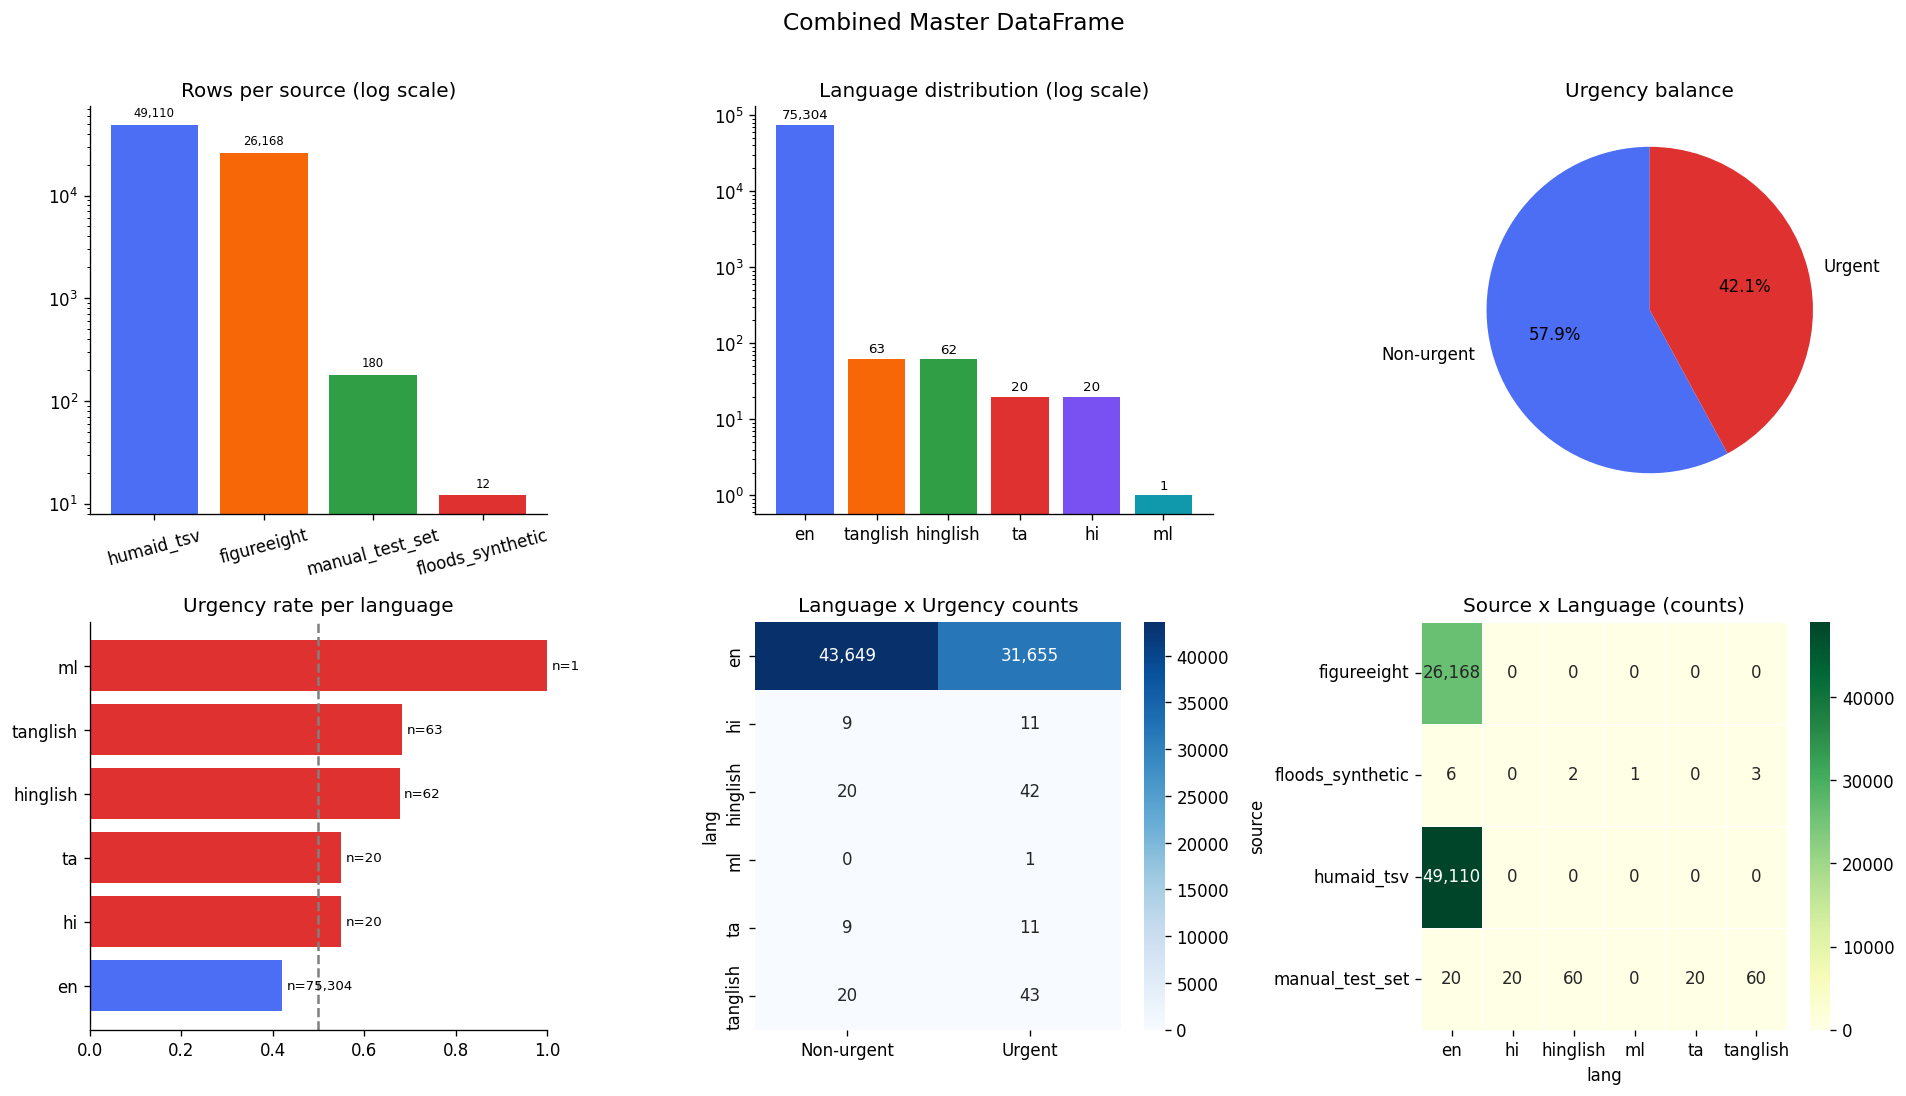

In [20]:
section('Master — overview plots')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sc = df_master['source'].value_counts()
axes[0,0].bar(sc.index, sc.values, color=C[:len(sc)])
axes[0,0].set_yscale('log')
axes[0,0].set_title('Rows per source (log scale)')
axes[0,0].tick_params(axis='x', rotation=15)
for i,v in enumerate(sc.values): axes[0,0].text(i, v*1.2, f'{v:,}', ha='center', fontsize=7)

lc = df_master['lang'].value_counts()
axes[0,1].bar(lc.index, lc.values, color=C[:len(lc)])
axes[0,1].set_yscale('log')
axes[0,1].set_title('Language distribution (log scale)')
for i,v in enumerate(lc.values): axes[0,1].text(i, v*1.2, f'{v:,}', ha='center', fontsize=8)

uc = df_master['urgency'].value_counts().sort_index()
axes[0,2].pie(uc.values, labels=['Non-urgent','Urgent'],
              colors=[C[0],C[3]], autopct='%1.1f%%', startangle=90)
axes[0,2].set_title('Urgency balance')

ul = df_master.groupby('lang')['urgency'].agg(['mean','count']).sort_values('mean')
axes[1,0].barh(ul.index, ul['mean'],
               color=[C[3] if v>0.5 else C[0] for v in ul['mean']])
axes[1,0].axvline(0.5, linestyle='--', color='gray')
axes[1,0].set_title('Urgency rate per language')
axes[1,0].set_xlim(0,1)
for i,(idx,row) in enumerate(ul.iterrows()):
    axes[1,0].text(row['mean']+0.01, i, f'n={int(row["count"]):,}', va='center', fontsize=8)

lu = pd.crosstab(df_master['lang'], df_master['urgency'])
lu.columns = ['Non-urgent','Urgent']
sns.heatmap(lu, annot=True, fmt=',d', cmap='Blues', ax=axes[1,1])
axes[1,1].set_title('Language x Urgency counts')

cov = pd.crosstab(df_master['source'], df_master['lang'])
sns.heatmap(cov, annot=True, fmt=',d', cmap='YlGn', ax=axes[1,2], linewidths=0.5)
axes[1,2].set_title('Source x Language (counts)')

plt.suptitle('Combined Master DataFrame', fontsize=14, y=1.01)
plt.tight_layout()
savefig('eda_08_master')
plt.show()

In [21]:
section('Gap Analysis')

lc = df_master['lang'].value_counts()
en_n = lc.get('en', 1)

print('Language imbalance vs English:')
print(f'{"Language":<12} {"Count":>8}  {"Ratio":>10}  Status')
print('-'*50)
for lang in config.LANGUAGES:
    n     = lc.get(lang, 0)
    ratio = en_n / n if n > 0 else float('inf')
    flag  = 'OK' if ratio < 10 else ('GAP' if ratio < 100 else 'SEVERE GAP')
    print(f'{lang:<12} {n:>8,}  {f"{ratio:.0f}x smaller":>10}  {flag}')

print('\nDataset purpose summary:')
print(f'{"Dataset":<12} {"Urgency train":>14} {"NER":>6} {"LangID":>8} {"Domain":>10}')
print('-'*55)
rows = [
    ('CrisisNLP',  'YES (EN)',    'NO',  'NO',  'disaster'),
    ('HumAID',     'YES (EN)',    'NO',  'NO',  'disaster'),
    ('WikiANN',    'NO',         'YES', 'NO',  'Wikipedia'),
    ('L3Cube',     'NO',         'NO',  'YES', 'social'),
    ('FIRE2021',   'NO',         'NO',  'YES', 'sentiment'),
    ('Floods',     'test only',  'NO',  'NO',  'disaster'),
    ('Manual(180)','eval only',  'eval','eval','disaster'),
]
for r in rows:
    print(f'{r[0]:<12} {r[1]:>14} {r[2]:>6} {r[3]:>8} {r[4]:>10}')

df_master['word_count'] = df_master['text'].str.split().str.len()
est = df_master['word_count'] * 1.3

print('\nKey settings for Week 2:')
print(f'  max_length=128 covers {(est<=128).mean():.1%} of all texts')
print(f'  95th percentile token estimate: {int(np.percentile(est.dropna(),95))}')
print(f'  Class imbalance: {df_master["urgency"].mean():.0%} urgent -> use F1 not accuracy')
print(f'  Resource labels: only in 180-sample test set -> rule-based extractor')
print(f'  Code-mixed gap : no disaster+Hinglish/Tanglish exists -> 120 samples IS the contribution')


  Gap Analysis
Language imbalance vs English:
Language        Count       Ratio  Status
--------------------------------------------------
en             75,304  1x smaller  OK
hi                 20  3765x smaller  SEVERE GAP
ta                 20  3765x smaller  SEVERE GAP
hinglish           62  1215x smaller  SEVERE GAP
tanglish           63  1195x smaller  SEVERE GAP

Dataset purpose summary:
Dataset       Urgency train    NER   LangID     Domain
-------------------------------------------------------
CrisisNLP          YES (EN)     NO       NO   disaster
HumAID             YES (EN)     NO       NO   disaster
WikiANN                  NO    YES       NO  Wikipedia
L3Cube                   NO     NO      YES     social
FIRE2021                 NO     NO      YES  sentiment
Floods            test only     NO       NO   disaster
Manual(180)       eval only   eval     eval   disaster

Key settings for Week 2:
  max_length=128 covers 99.9% of all texts
  95th percentile token estimate: 5

In [22]:
section('Saving master_clean.csv')

save_cols = [c for c in ['text','lang','urgency','class_label','event','split','source','region','resources']
             if c in df_master.columns]

out_path = f'{config.DATA_PROC}/master_clean.csv'
df_master[save_cols].to_csv(out_path, index=False)
print(f'Saved {len(df_master):,} rows -> {out_path}')

print('\nAll plots saved:')
for f in sorted(os.listdir(config.OUT_PLOTS)):
    if f.endswith('.png') and f.startswith('eda_'):
        print(f'  {f}')

print('\nEDA complete. Next: week2_nlp_pipeline.ipynb')


  Saving master_clean.csv
Saved 75,470 rows -> /content/drive/MyDrive/Equi-Relief/data/processed/master_clean.csv

All plots saved:
  eda_01_crisisnlp.png
  eda_01_crisisnlp_words.png
  eda_03_wikiann.png
  eda_06_floods.png
  eda_07_testset.png
  eda_07_testset_coverage.png
  eda_08_master.png

EDA complete. Next: week2_nlp_pipeline.ipynb
